# Exercise 3: Time series with ARIMA

## Do not start the exercise until you fully understand the submission guidelines.

- The homework assignments are executed automatically.
- Failure to comply with the following instructions will result in a significant penalty.
- Appeals regarding your failure to read these instructions will be denied.
- Kind reminder: the homework assignments contribute 60% of the final grade.

## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your ID as the file name. For example, `hw1_123456789_987654321.zip` if you submitted in pairs and `hw1_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.

Please use only a **zip** file in your submission.

---

---

## Please sign that you have read and understood the instructions:

316492776
318900016

---

---


In [1]:
!pip3 install -q statsmodels seaborn numpy pandas scikit-learn yfinance

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from statsmodels.graphics import tsaplots
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression

sns.set_theme()
np.random.seed(42)

# Algorithm overview

Make sure to describe the algorithm, its limitations, and describe use-cases.


ARIMA - AutoRegressive Integrated Moving Average is a statistical algorithm for time series forecasting.

It consists of 3 parts:

1. Auto Regression (AR) - Use past observations in order to predict next values
2. Integration (I) - Differentiate data in units in order to work with stationarity data
3. Moving Average (MA) - Estimate errors in order to tune future predictions

Its main focus is forecasting future values based on past values in time series with stationary data (or an integration of stationary data) and its best for use cases which the data has a strong correlation. Examples of such cases are stock price prediction, sales and inventory levels prediction.

However, when the data doesn't have a stationarity and constant trend patterns, ARIMA may fail to make a useful forecasting.
In this project we're going to use a real dataset which is a typical one for ARIMA algorithm - the daily stock price of Amazon inc. since it has been started trading untill lately.


# Your implementations

You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.


Our implementation consists on ARMA base class with a "layer" of differentiation upon it which makes it ARIMA. We implemented this using inheritance,
which makes the code short, readable and easy to extend. We made sure that everything is vectorized and avoided loops as much as we could.
In terms of extra features we added:

- an option to manually pass the order of the ARIMA (p,d,q). By default these parameters are automatically deduced from the given data using ACF and PACF values as seen in the lecture.
- verbosity option for easy debugging
- the ability to calibrate the also the autocorrelation significance threshold. A large thrshold means less parameters hence a simpler model, at the risk of underfitting. Smaller threshold will cause more parameters and risk overfitting.

The implementation works as follows:

1. [ARIMA only, if d is not set] Differentiation is calculated - the decision whether to differentiate is taken based on the stationarity of the data, which we calculate using Augmented Dickey–Fuller test. We allow d to be only 0,1 or 2, since higher orders are very unlikely to occur naturally.
2. [if p,q are not set] We calculate p,q - as seen in class, we calculate ACF and PACF values, setting p,d according to where the correlation stops being significant.
3. We fit the AR model - using the last p observations to predict the next one, we fit a linear regressor to find the best $\phi_i$ for the given data.
4. We fit the MA model - using the last q _errors_ (which are calculated by the difference between the actual value and the AR estimation) to predict the next error we decide what should be the correction to tweak the AR. We again use a (different) linear regressor to find the best $\theta_j$.
5. Now that the model is calibrated, we can predict the next values using $x_t=\sum_{i=1}^{p}{\phi_i x_{t-i}}+\sum_{j=1}^{q}{\theta_j w_{t-j}}$ with the parameters computed before and noise estimation in each prediction step.
6. [ARIMA only, if d > 0] Since we run on differentiated values we need to integrate back to the get the data and not its derivatives.


In [8]:
class ARMACustom:
    def __init__(
        self,
        X: np.ndarray,
        order: tuple = (None, None),
        verbose: bool = False,
        ac_thresh: float = 0.1,
    ):
        self.verbose = verbose
        self.ac_thresh = ac_thresh
        self.X = X
        self.order = order
        self.set_params()

    def set_params(self):
        self.p, self.q = self.order

    def fit(self) -> None:
        self.find_p()
        self.find_q()
        self.fit_AR()
        self.fit_MA()

    def find_p(self) -> None:
        if self.p is not None:
            return None
        X_pacf = pacf(self.X)
        p = np.argmax(np.abs(X_pacf) < self.ac_thresh)
        if self.verbose:
            print(f"p: {p}")
            print(f"pacf: {X_pacf}")
        assert 0 < p < len(self.X), "Cannot fit AR model to the given data"
        self.p = p

    def find_q(self) -> None:
        if self.q is not None:
            return None
        X_acf = acf(self.X)
        q = np.argmax(np.abs(X_acf) < self.ac_thresh)
        if self.verbose:
            print(f"q: {q}")
            print(f"acf: {X_acf}")
        assert 0 < q < len(self.X), "Cannot fit MA model to the given data"
        self.q = q

    def fit_AR(self) -> None:
        data = np.vstack([self.X[i - self.p : i] for i in range(self.p, len(self.X))])
        labels = self.X[self.p : len(self.X)]
        reg = LinearRegression().fit(data, labels)
        self.phi_ = reg.coef_
        # TODO: for some reason the fits are completely different

    def fit_MA(self) -> None:
        w = np.zeros(len(self.X))
        for i in range(self.p, len(self.X)):
            ar = (self.phi_ * self.X[i - self.p : i]).sum()
            w[i] = self.X[i] - ar
        # we start from p+q since it is the first index that allows full derivation of errors looking back in time
        labels = self.X[self.q + self.p : len(self.X)]
        data = np.vstack(
            [w[i - self.q : i] for i in range(self.q + self.p, len(self.X))]
        )
        reg = LinearRegression().fit(data, labels)
        self.theta_ = reg.coef_

    def forecast(self, steps: int) -> np.ndarray:
        n = len(self.X)
        preds = np.concatenate([self.X, np.zeros(steps)])
        noise_preds = np.zeros_like(preds)  # same size for vectorization
        for i in range(
            n - self.p, n + steps
        ):  # we go back p steps to estimate the noise
            ar = (self.phi_ * preds[i - self.p : i]).sum()
            ma = (self.theta_ * noise_preds[i - self.q : i]).sum()
            if i >= n:
                preds[i] = ar + ma  # we change only future indexes
            else:
                noise_preds[i] = (
                    preds[i] - ar - ma
                )  # will be 0 for new indexes, since we don't know X[i] for i >= n
        return preds[n:]


class ARIMACustom(ARMACustom):
    def __init__(
        self,
        X: np.ndarray,
        order: tuple = (None, None, None),
        verbose=False,
        ac_thresh: float = 0.1,
        stationarity_conf: float = 0.05,
    ):
        super().__init__(X, order, verbose, ac_thresh)
        self.stationarity_conf = stationarity_conf

    def set_params(self):
        self.p, self.d, self.q = self.order

    def find_d(self) -> None:
        if self.d is not None:
            return None
        for d in [0, 1, 2]:  # no more than a second derivative
            p_val = adfuller(np.diff(self.X, d))[1]  # p-value
            if p_val < self.stationarity_conf:
                if self.verbose:
                    print(f"p_val: {p_val}")
                    print(f"d: {d}")
                self.d = d
                return None
        raise Exception("Data is not stationary, even after differentiating twice")

    def fit_I(self) -> None:
        self.Z = self.X  # to maintain inheritance
        self.X = np.diff(self.X, self.d)

    def fit(self) -> None:
        self.find_d()
        self.fit_I()
        super().fit()

    def forecast(self, steps: int) -> np.ndarray:
        match self.d:
            case 0:
                return super().forecast(steps)
            case 1:
                # TODO: fix because Z[-1] is repeated twice (maybe just remove it)
                dx = np.insert(super().forecast(steps).cumsum(), 0, 0) + self.Z[-1]
                dx = super().forecast(steps).cumsum() + self.Z[-1]
                return super().forecast(steps).cumsum() + self.Z[-1]
            case 2:
                # insert 0 at the beggining to maintain size
                dx = (
                    np.insert(super().forecast(steps - 1).cumsum(), 0, 0)
                    + self.Z[-1]
                    - self.Z[-2]
                )
                return dx.cumsum() + self.Z[-1]
            case _:
                raise Exception(f"self.d={self.d} which is invalid")

# A sample dataset

Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.


For the sample data (Unit Test), we chose to use a sample dataset from Kaggle https://www.kaggle.com/datasets/prashant111/dataset. This is a simple dataset that contains a sample time series data with two columns:

1. date -> with a format of YYYY-MM-DD
2. value -> a sample numeric value


In [4]:
path = "./sample_dataset.csv"

sample_dataset = pd.read_csv(path)

sample_dataset.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [5]:
X = sample_dataset["value"].values
a = ARIMACustom(X)

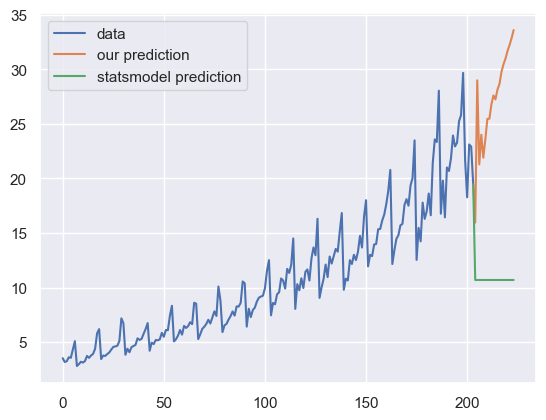

In [9]:
our_model = ARIMACustom(X)
our_model.fit()
statsmodel_model = ARIMA(X)
statsmodel_model = statsmodel_model.fit()
steps = 20

our_forecast = our_model.forecast(steps)
statsmodel_forecast = statsmodel_model.get_forecast(steps).predicted_mean
plt.plot(X, label="data")
plt.plot(
    range(len(X) - 1, len(X) + steps),
    np.insert(our_forecast, 0, X[-1]),
    label="our prediction",
)
plt.plot(
    range(len(X) - 1, len(X) + steps),
    np.insert(statsmodel_forecast, 0, X[-1]),
    label="statsmodel prediction",
)
plt.legend()

In [9]:
date_filter = sample_dataset["date"].loc[sample_dataset["date"].str.endswith("01-01")]
date_filter

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object

In [12]:
result = adfuller(sample_dataset.value.dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Statistic: 3.145185689306738
p-value: 1.0


In [13]:
def plot_acf(values, title, samples_per_lag):

    plt.rcParams.update({"figure.figsize": (20, 5), "figure.dpi": 120})

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    # Original Series ACF
    axes.plot(values)
    axes.set_title(title)

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values, lags=samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values, lags=samples_per_lag, ax=axes[1])

    # 1st Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff())
    axes.set_title(f"{title} - 1st Order Differencing")

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().dropna(), lags=samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values.diff().dropna(), lags=samples_per_lag, ax=axes[1])

    # 2nd Differencing ACF
    fig, axes = plt.subplots(1, 1, sharex=True)
    axes.plot(values.diff().diff())
    axes.set_title(f"{title} - 2nd Order Differencing")

    # Create subplot for ACF
    fig, axes = plt.subplots(1, 2, sharex=True)
    tsaplots.plot_acf(values.diff().diff().dropna(), lags=samples_per_lag, ax=axes[0])
    tsaplots.plot_pacf(values.diff().diff().dropna(), lags=samples_per_lag, ax=axes[1])

    plt.show()

# Arima demonstration

Demonstrate your Arima implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the statsmodels implementation. Hint: you can look at the documentation.


In order to demonstrate the Arima implementation, we configured the following graphs and plots:

The first graphs sections focused on the stationarity and the correlation between the value, without making forecasts

1. A simple graph of the original dataset with the "date" as X-axis and "value" as Y-axis
2. Auto-correlation (ACF) graph of the original dataset - ACF is a method to find a correlation different time lags. This method seperates the data into some time lags (We used a month as a time lag -> Each lag contains 30 samples). The X-axis is the lag number (If a lag contains 30 samples, there are 12 lags in a period of year) and the Y-axis is the correlation between lag T and lag T-1. 1 -> Strong positive correlation (Increase with the same trend). -1 -> Strong negative correlation (Decrease after increase and vice versa) and 0 -> no any correlation
3. Partial auto-correlation (PACF) graph of the original dataset - PACF is similar to ACF but measures a dirrect correlation between lag T and lag T-1 with no attention to all the samples inside lag T-1 (Despite ACF that measures the correlation day-to-day, PACF measures the direct correlation between 1st day of month T-1 to 1st day of month T)
4. In addition, we include graphs of the 1st and 2nd differences of the original dataset, including the ACF and PACF values of the differences (In a 1st order difference, each value is v(i)-v(i-1) and in 2nd order difference, each value is v(i)-2v(i-1)+v(i-2)). That's in order to measure the stationarity between the values in the graph and the correlation between them
5. Each one of the 1st and 2nd differences graphs contains also the ACF and PACF values

The second part includes a forecasting of a various of examples with the following graphs:

1. Residuals / Density in order to measure the performance of the model (Can be thought as the loss values)
2. A graph that contains the original dataset values as a function of the time units, but with some differences:
   - The left part of the graph contains the first X% part of the dataset as it's original values (Train set). This data part is being fitted by the model
   - The right part of the graph contains the remaining (100-X)% part of the dataset with both it's original values (Test set) and it's forecast values: One forecast by the custom ARIMA model and the other by the StatsLib ARIMA model
   - The forecast values are also covered by a gray area which indicates the lower and upper standard deviation of the forecasted value. If the forecast is done well, the true value of the test set should be inside the standard deviation


In [14]:
def run_arima_train_test(dataset, param, date_label):
    print("Train / Test based on:")

    split = int(len(dataset) * param["train_rate"])
    train_dataset = dataset[:split]
    test_dataset = dataset[split:]

    for k, v in param.items():
        print(f"{k} -> {v}")

    model = ARIMA(
        train_dataset.value,
        order=(0, 0, 0) if param["order"] == (None, None, None) else param["order"],
    )
    model_fit = model.fit()

    custom_model = ARIMACustom(train_dataset.value.values, order=param["order"])
    custom_model.fit()

    plt.rcParams.update({"figure.figsize": (20, 5), "figure.dpi": 120})
    residuals = pd.DataFrame(model_fit.resid)
    fig, ax = plt.subplots(1, 2)
    residuals.plot(title=f'Residuals for order={param["order"]}', ax=ax[0])
    residuals.plot(kind="kde", title=f'Density for order={param["order"]}', ax=ax[1])
    plt.show()

    forecast = model_fit.get_forecast((len(dataset) - split), alpha=0.05)  # 95% conf
    forecast_df = pd.DataFrame(
        {"date": test_dataset["date"], "value": forecast.predicted_mean}
    )

    custom_forecast = custom_model.forecast((len(dataset) - split))
    custom_forecast_df = pd.DataFrame(
        {"date": test_dataset["date"], "value": custom_forecast}
    )

    # print(type(forecast))
    plt.plot(
        list(train_dataset["date"]), list(train_dataset["value"]), label="training"
    )
    plt.plot(list(test_dataset["date"]), list(test_dataset["value"]), label="actual")
    plt.plot(
        list(forecast_df["date"]),
        list(forecast_df["value"]),
        label="forecast - statsmodel",
    )
    plt.plot(
        list(custom_forecast_df["date"]),
        list(custom_forecast_df["value"]),
        label="forecast - custom",
    )
    plt.fill_between(
        list(forecast_df["date"]),
        forecast.conf_int().iloc[:, 0],
        forecast.conf_int().iloc[:, 1],
        color="k",
        alpha=0.15,
    )
    plt.xticks(date_label, rotation=30)
    plt.legend()
    plt.title(f'Training / Actual vs forecast for order={param["order"]}')
    plt.show()

    return forecast_df

ACF / PACF of original data


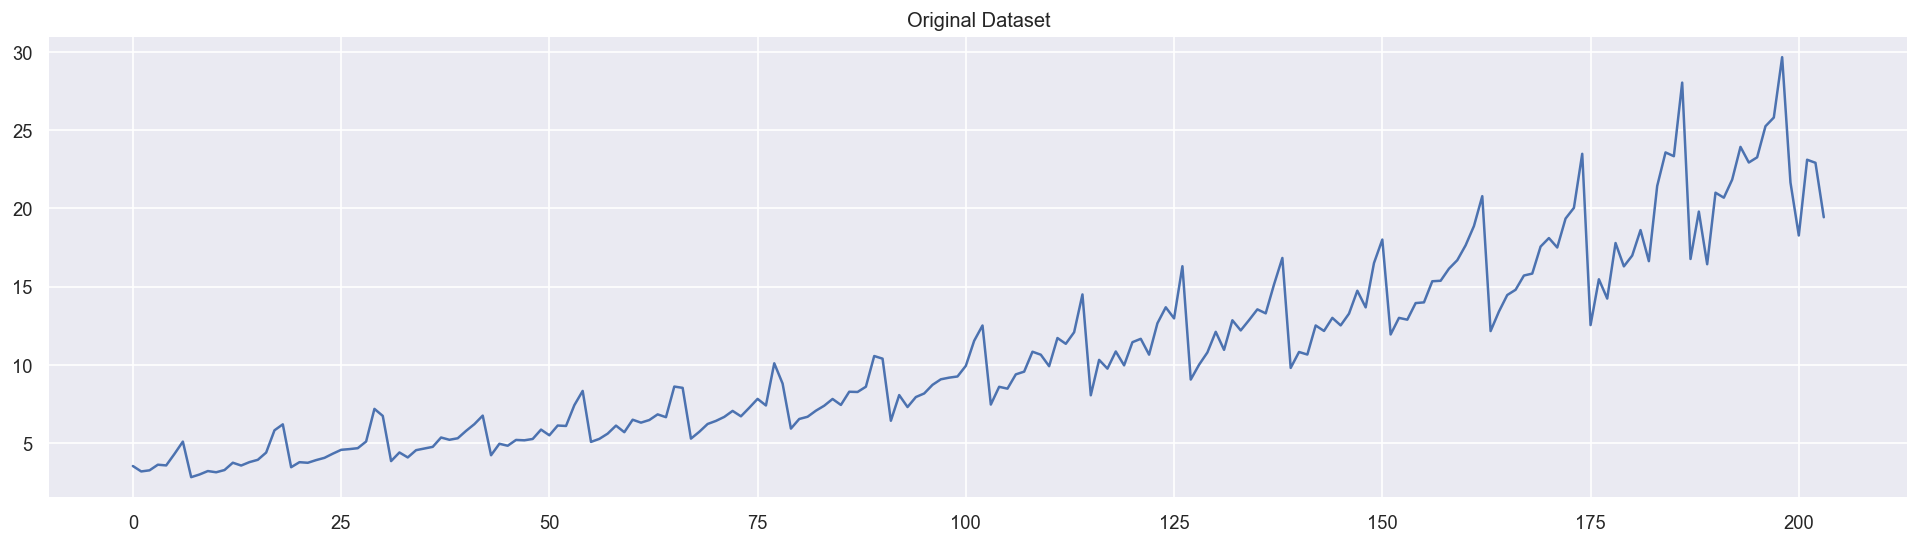

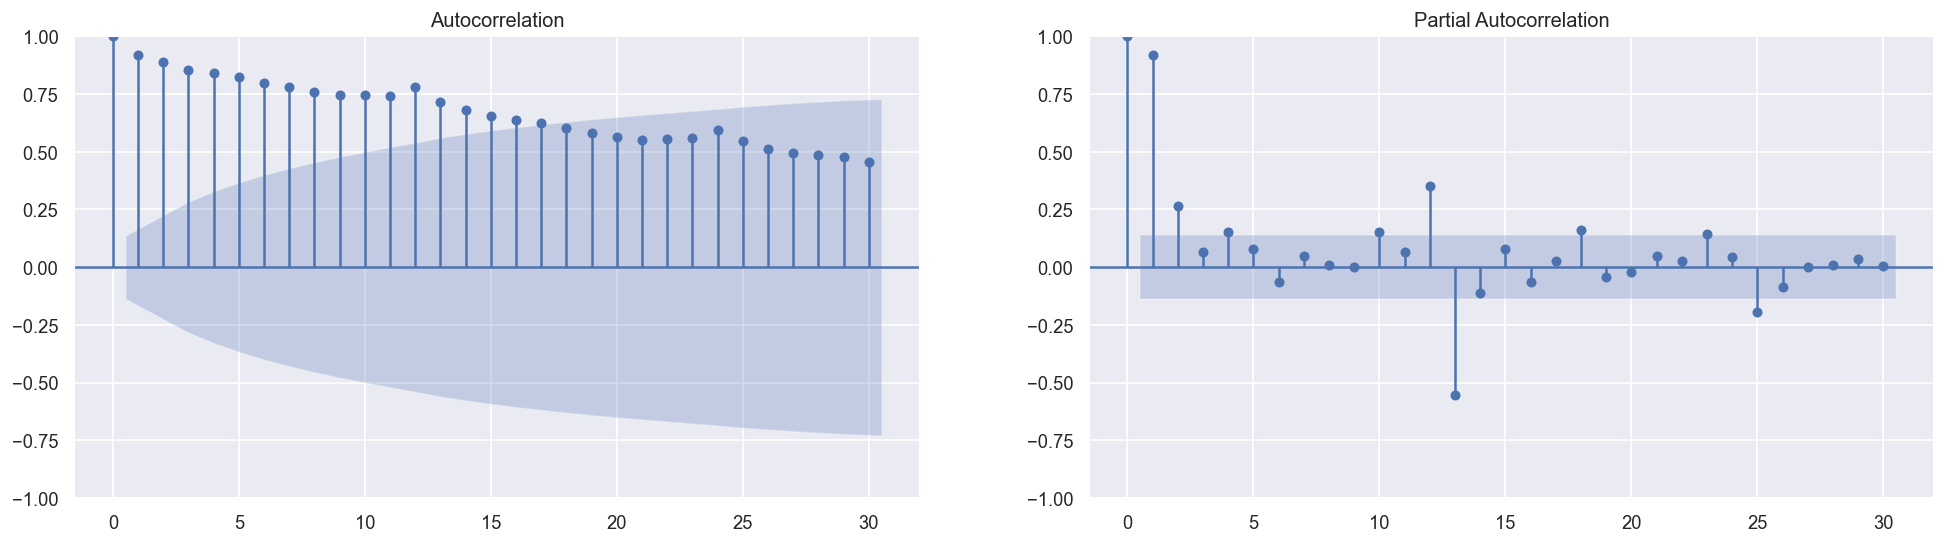

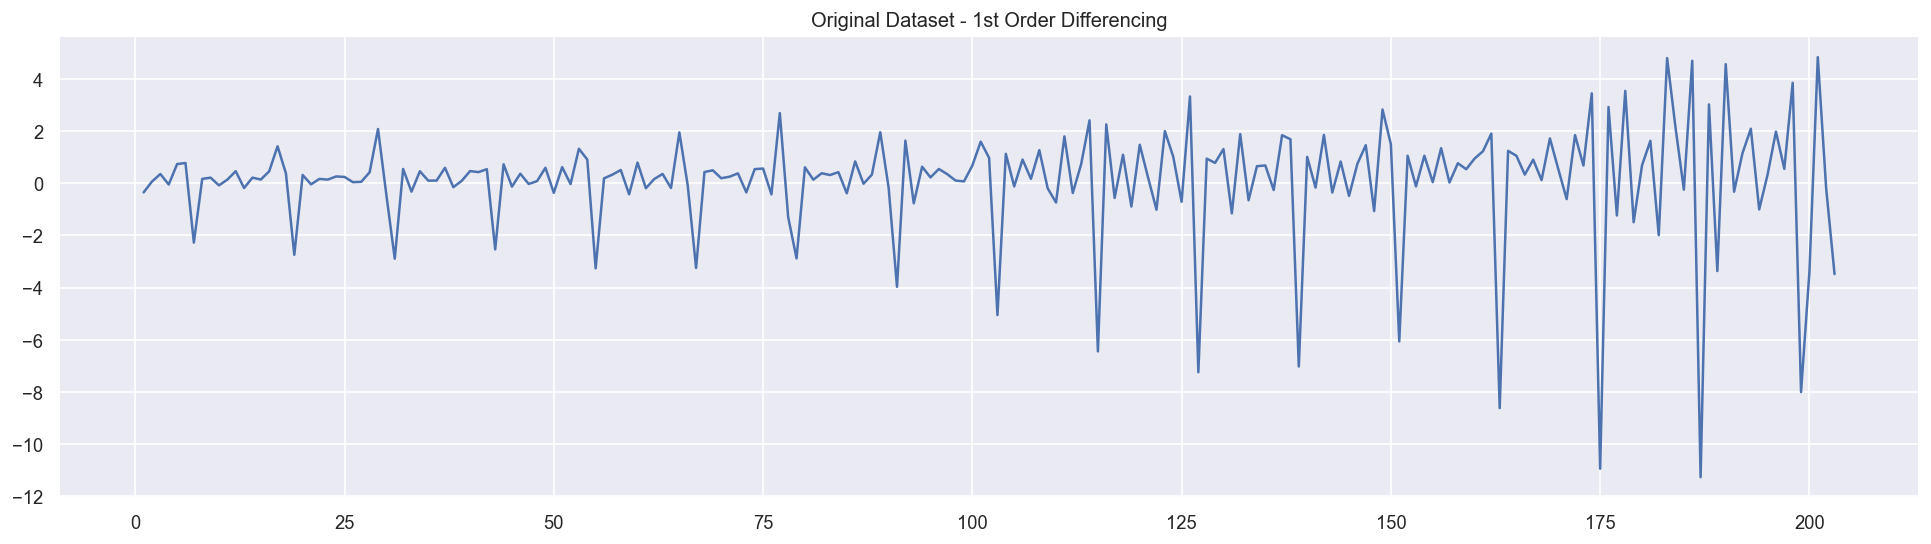

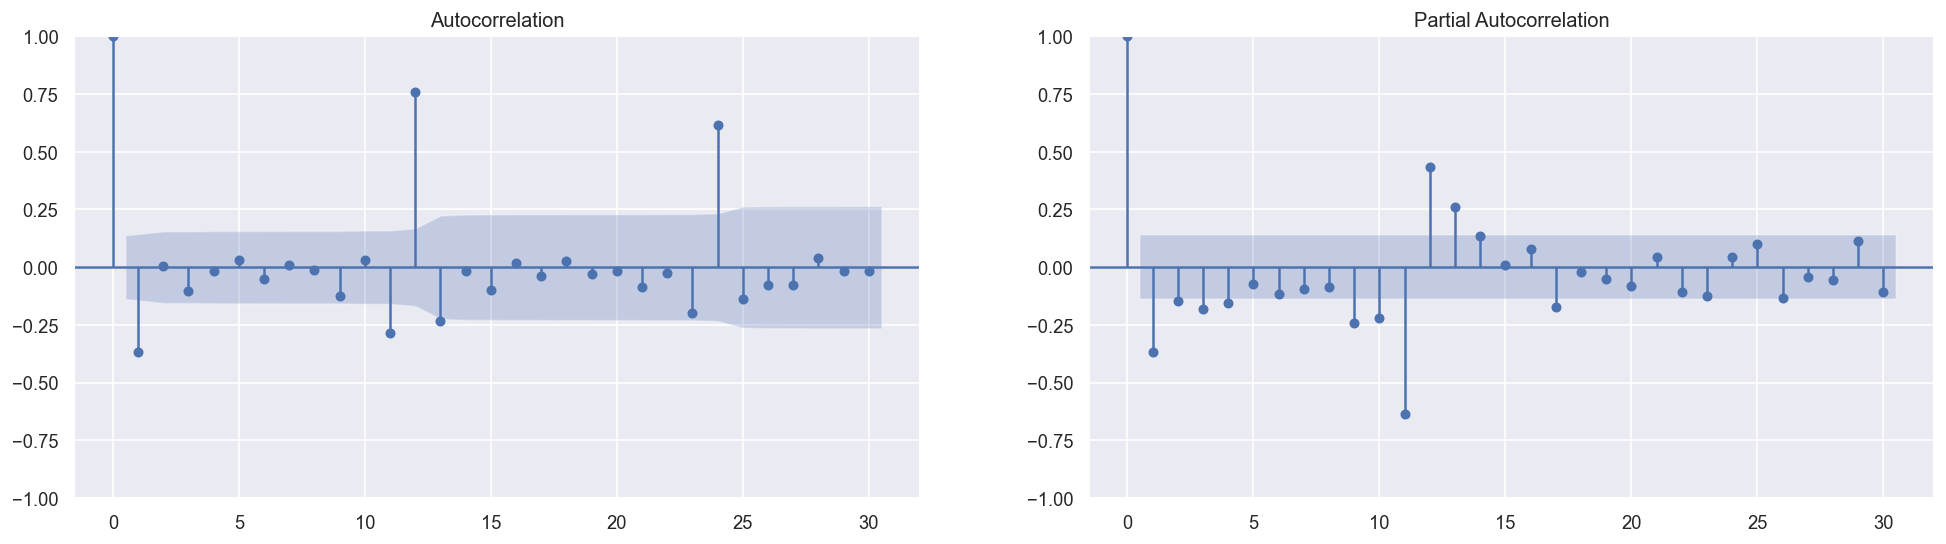

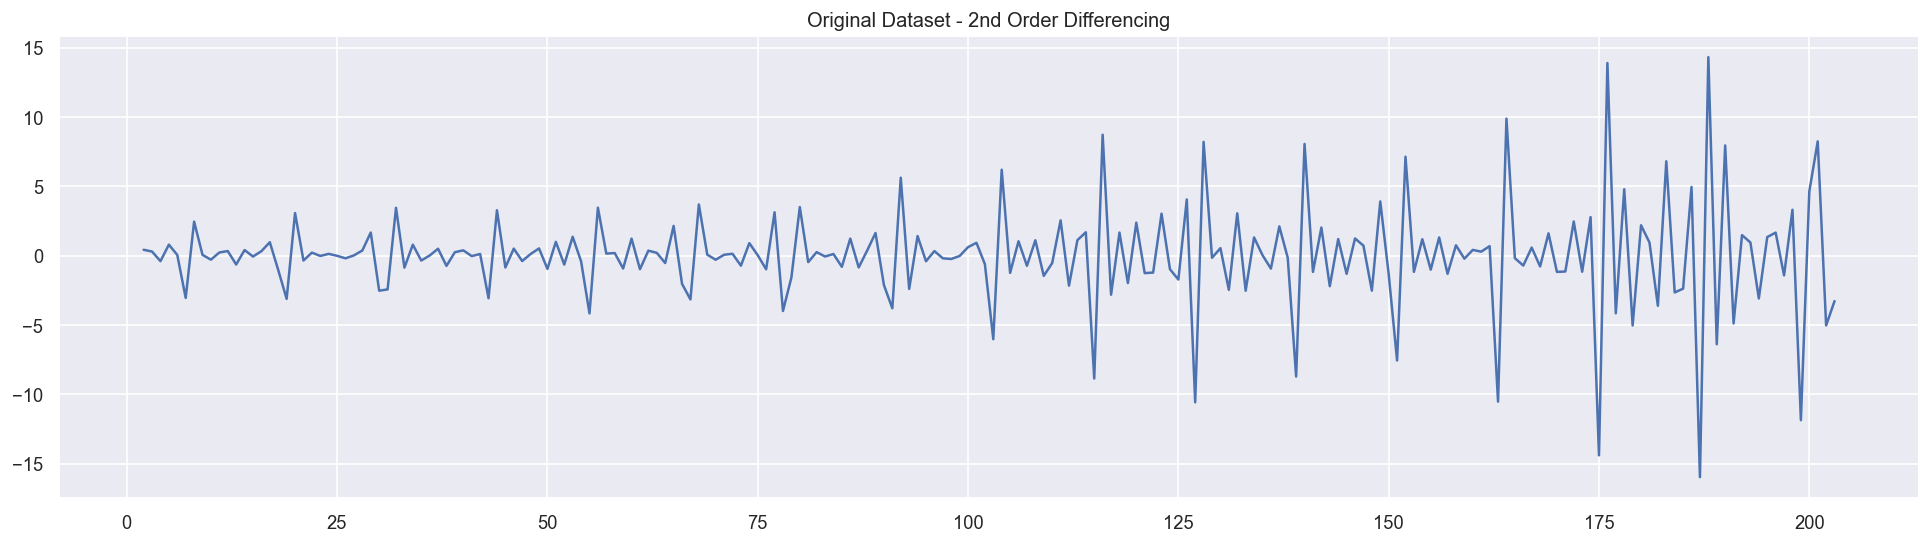

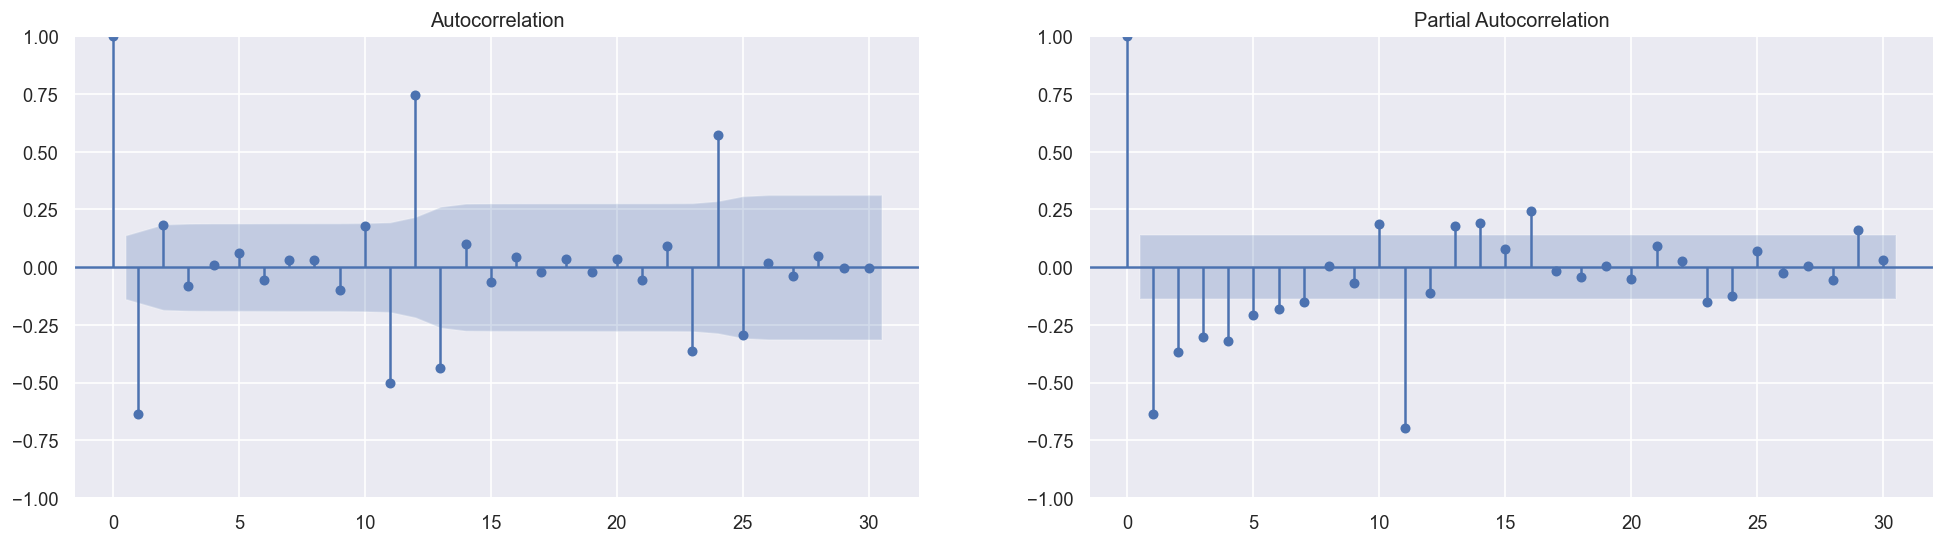

6      1992-01-01
18     1993-01-01
30     1994-01-01
42     1995-01-01
54     1996-01-01
66     1997-01-01
78     1998-01-01
90     1999-01-01
102    2000-01-01
114    2001-01-01
126    2002-01-01
138    2003-01-01
150    2004-01-01
162    2005-01-01
174    2006-01-01
186    2007-01-01
198    2008-01-01
Name: date, dtype: object
Train / Test based on:
order -> (5, 2, 5)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


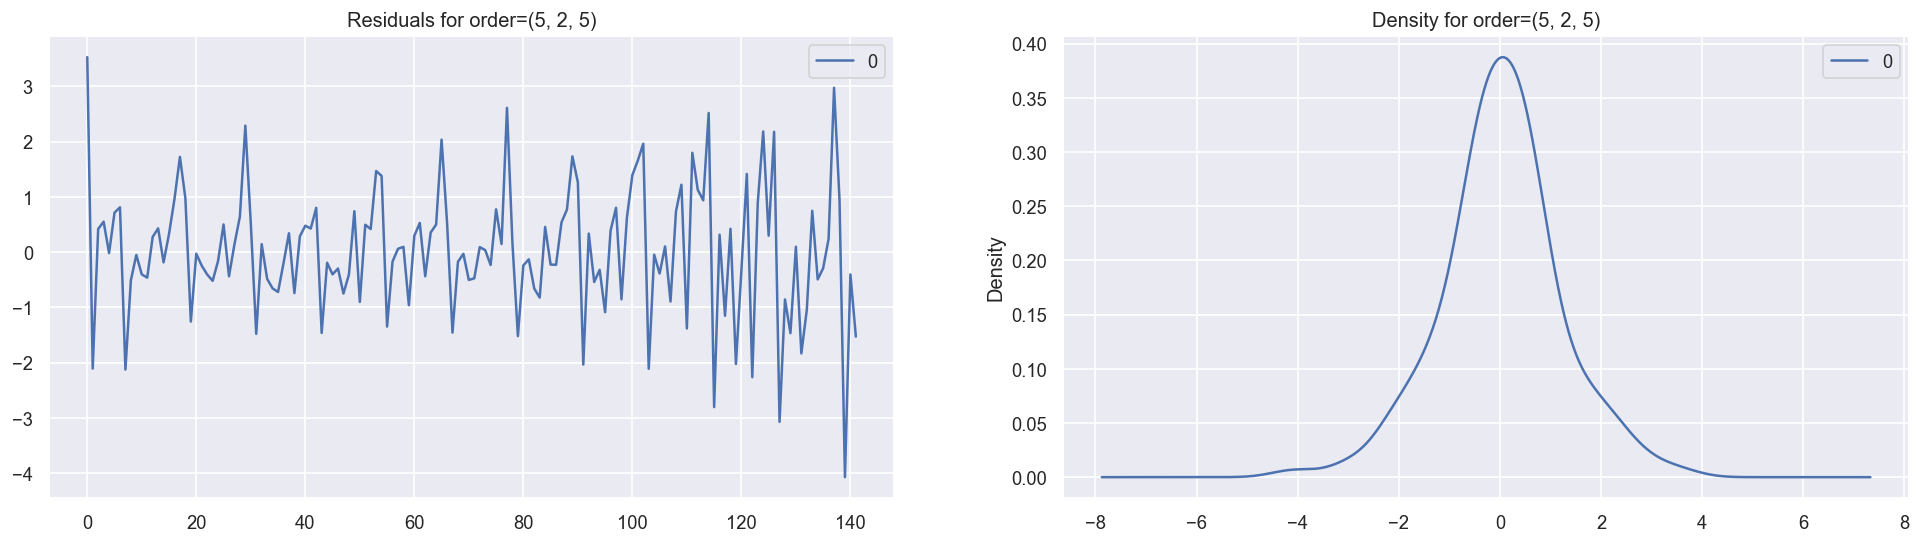

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


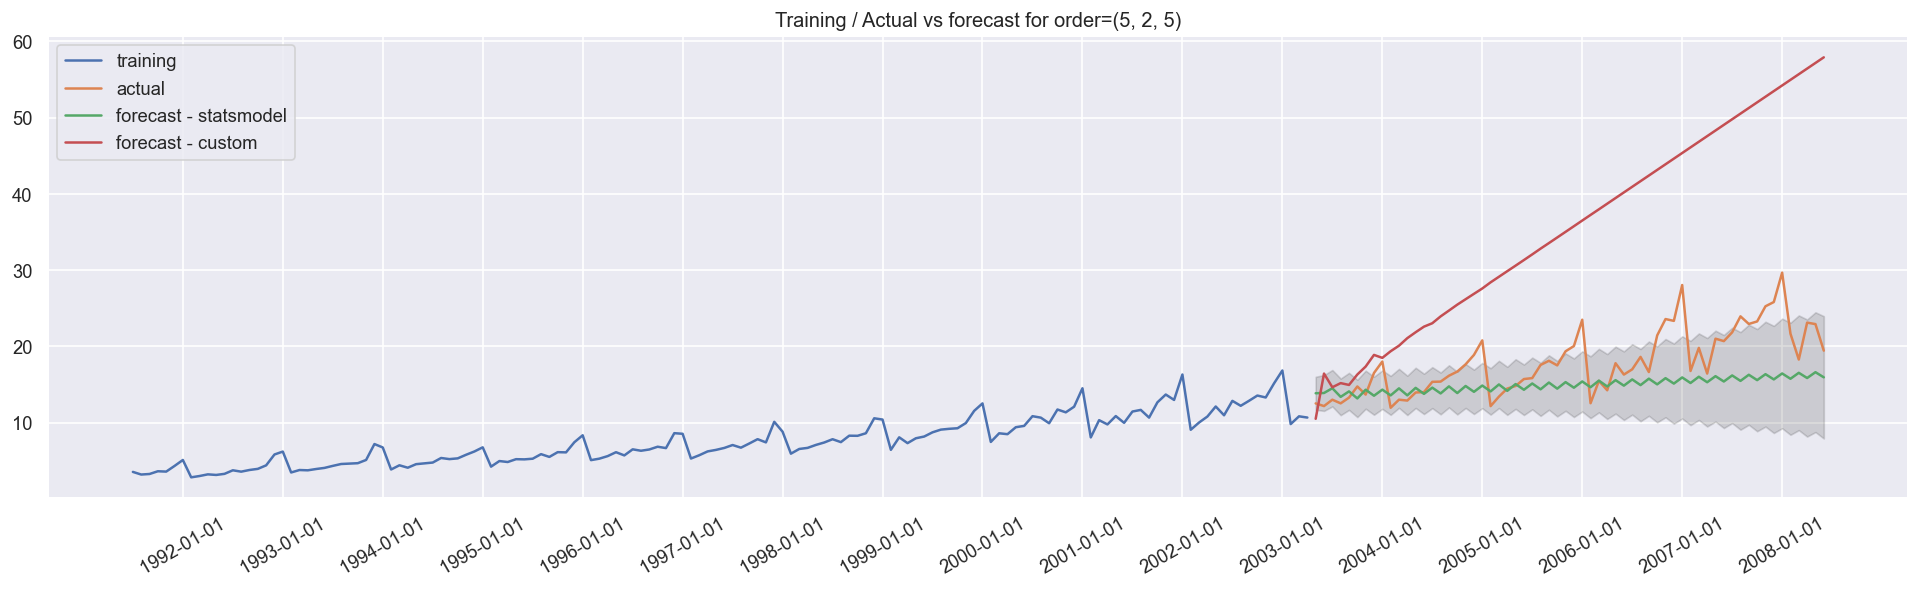

Train / Test based on:
order -> (5, 1, 5)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


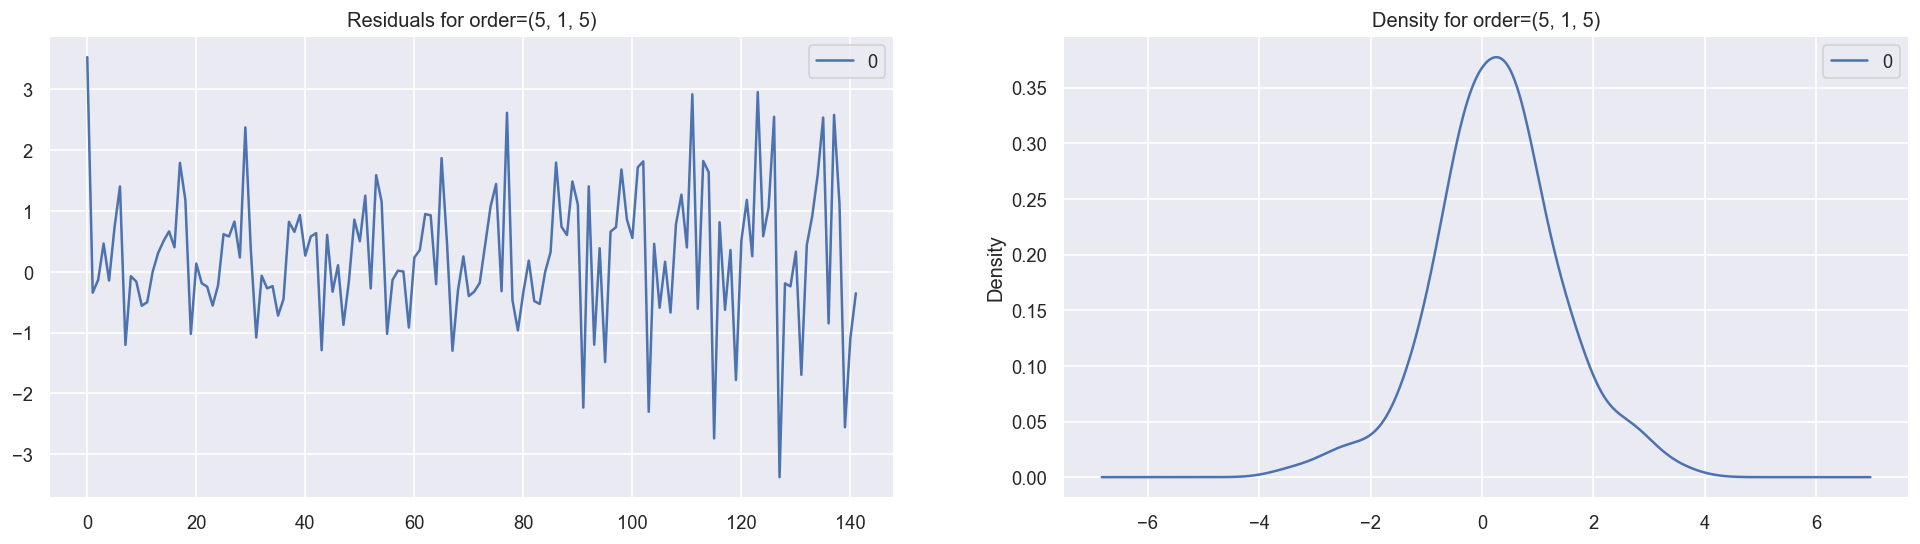

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


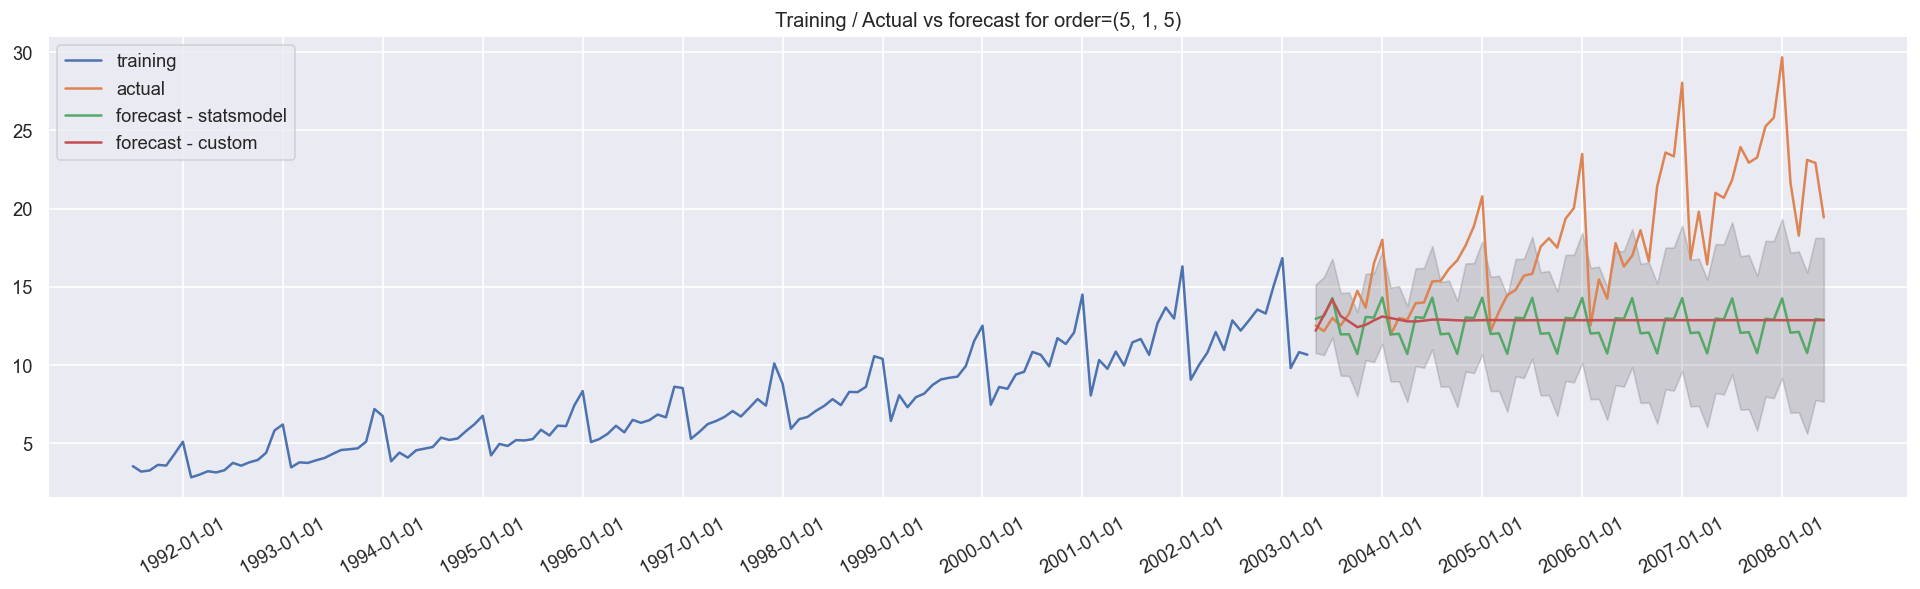

Train / Test based on:
order -> (12, 1, 12)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


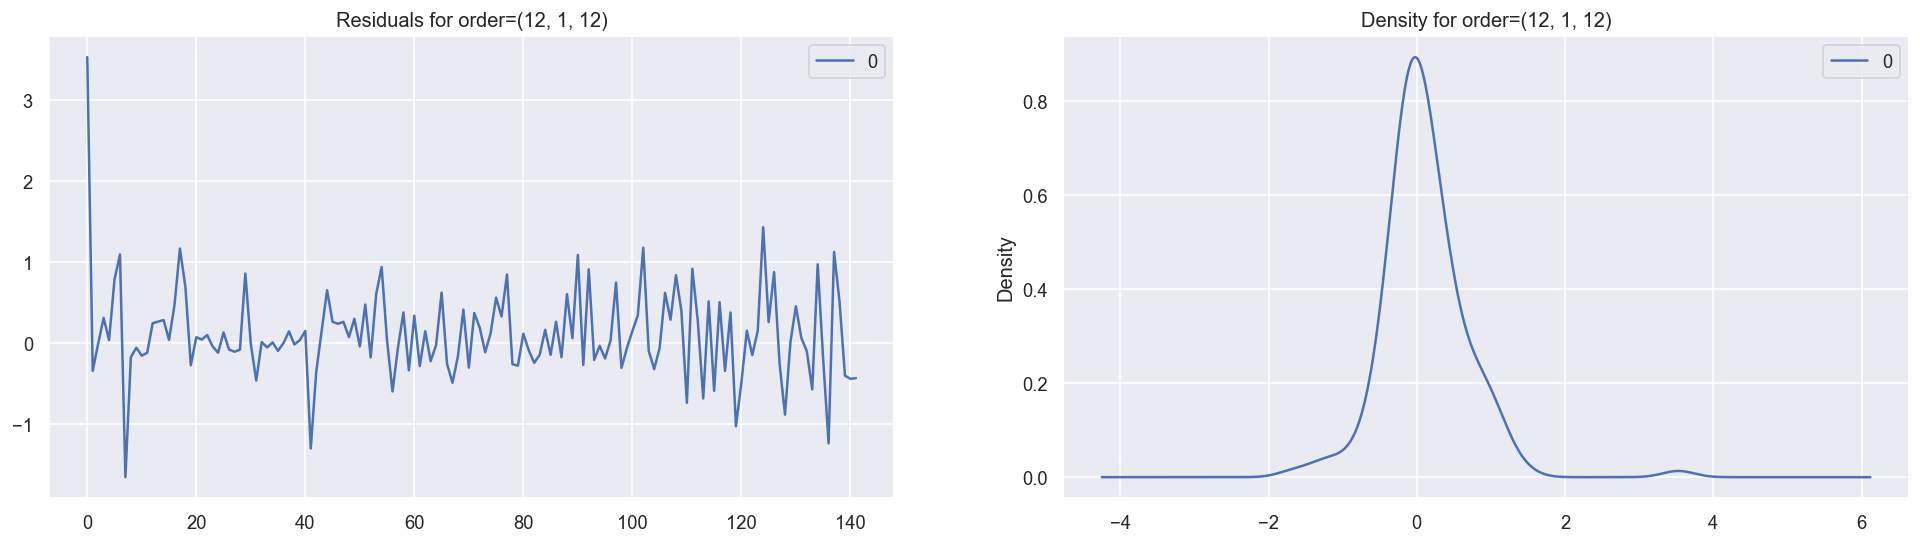

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


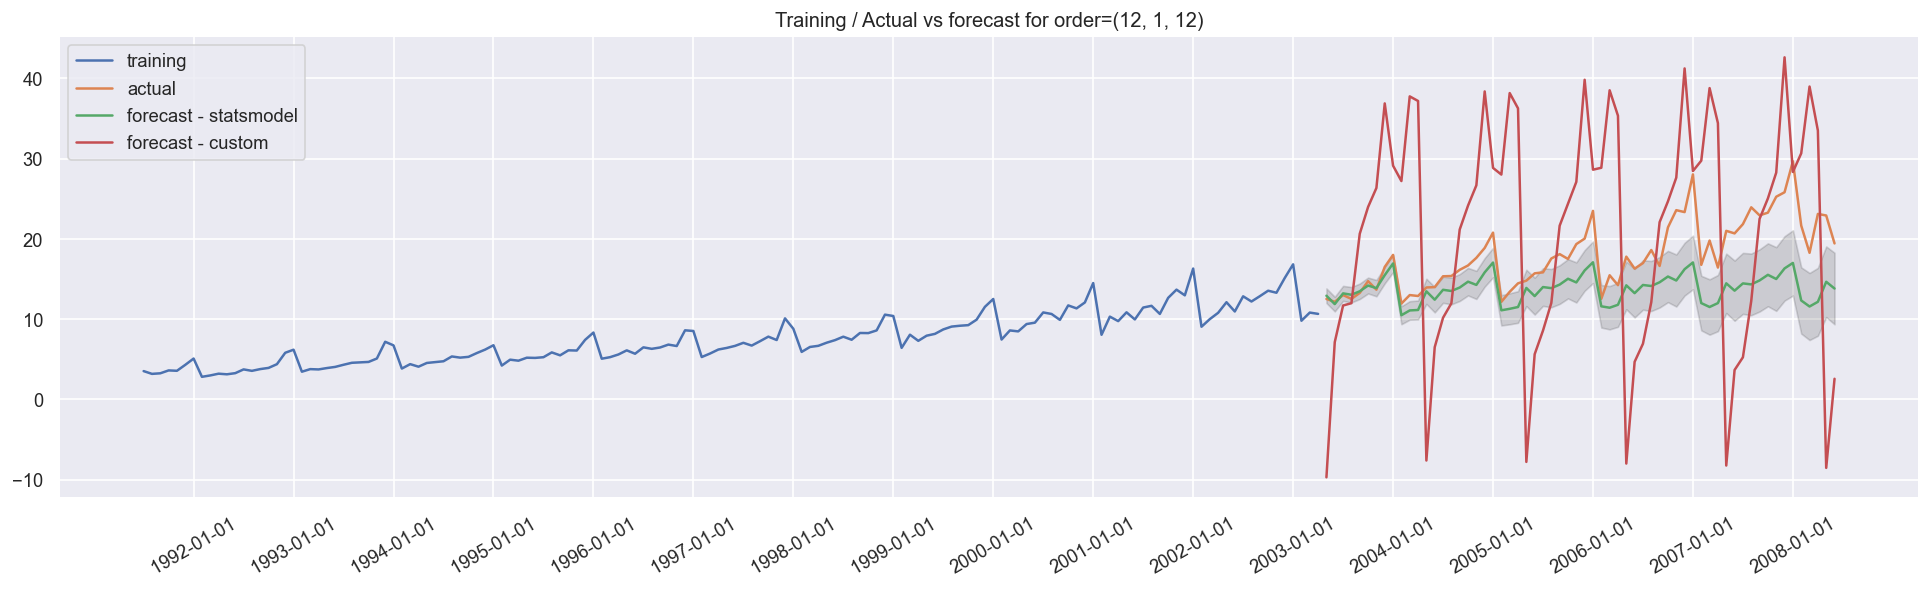

Train / Test based on:
order -> (5, 0, 5)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


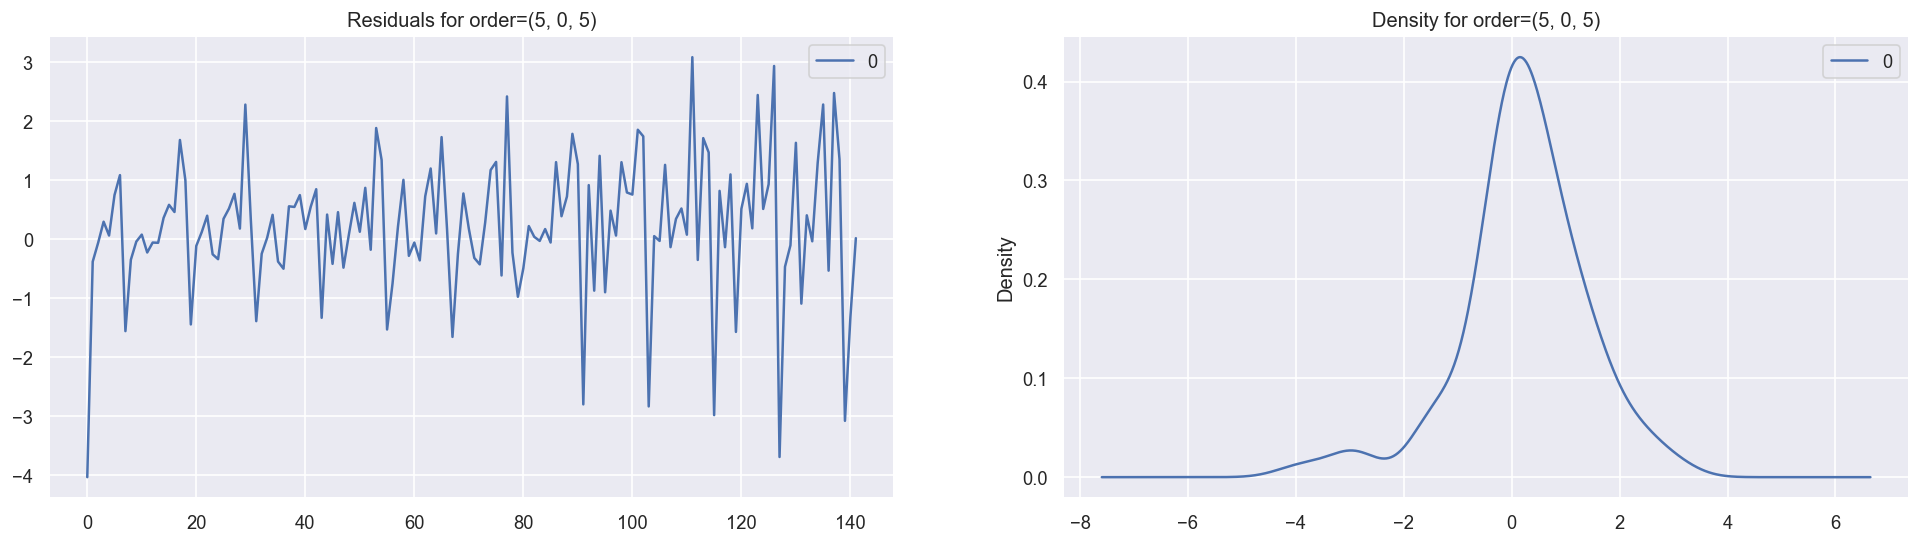

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


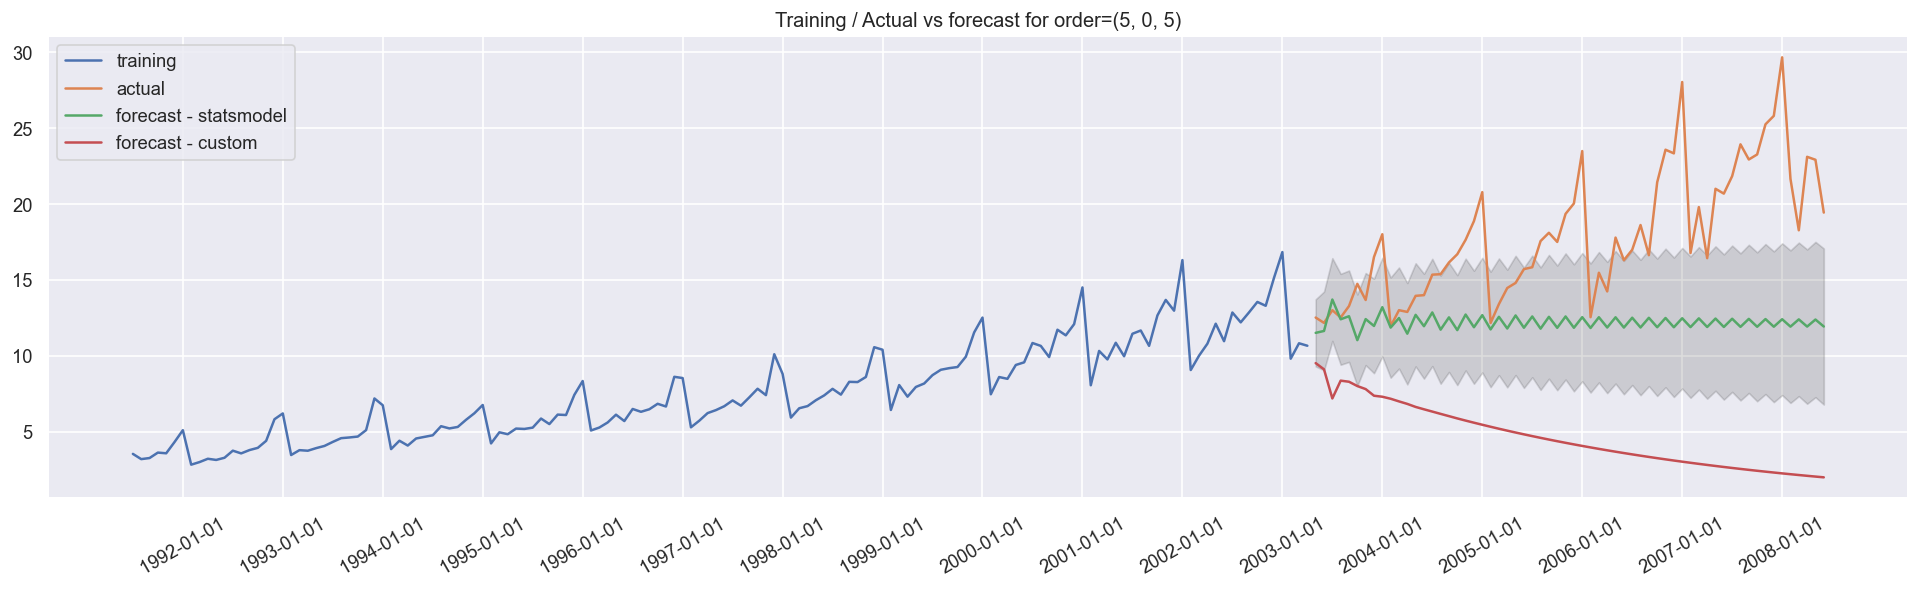

In [15]:
hyperparams = [
    {"order": (5, 2, 5), "train_rate": 0.7},
    {"order": (5, 1, 5), "train_rate": 0.7},
    {"order": (12, 1, 12), "train_rate": 0.7},
    {"order": (5, 0, 5), "train_rate": 0.7},
]

# Monthly correlation
SAMPLES_PER_LAG = 30

print("ACF / PACF of original data")
plot_acf(sample_dataset.value, "Original Dataset", SAMPLES_PER_LAG)
print(
    "=================================================================================================="
)
date_label = sample_dataset["date"].loc[sample_dataset["date"].str.endswith("01-01")]

print(date_label)
for idx, param in enumerate(hyperparams):
    predicted_dataset = run_arima_train_test(sample_dataset, param, date_label)
    print(
        "=================================================================================================="
    )

# AMZN Dataset


We used the stock information of Amazon directly using the Yahoo Finance package (Not the static file provided in the exercise). And we made the following pre-process:

1. The "Date" field contained an ISO format "YYYY-MM-DD hh:mm:ss.ms" and we converted it just to YYYY-MM-DD
2. We made two measures base on this dataset: The first measure is the mean stock price per day ((High - Low) / 2) and the second one is the Volume per day
3. While printing the X-values in the graphs, in order to make it clean to read, we printed just yearly timestamps (We took the first commerce day of a fiscal year as an X label) + The first and last values

We tested the performance based on 2 hyperparameters:

1. Split rate between train set and test (forecasted) set
2. The ARIMA order parameters p d and q
   - p is the number of previous values we want to use in order to predict the forecasted values
   - d is the number of differences we want to use (1: v(x)-v(x-1) 2: v(x)-v(x-1)-(v(1)-v(x-2))) (Usually we set it to 1 or 2)
   - q is the number of previous forecast error values we want to use in order to predict the next forecasted values


In [ ]:
ticker = yf.Ticker("AMZN")

amzn_dataset_original = ticker.history(period="max").reset_index()
amzn_dataset_original["Date"] = amzn_dataset_original["Date"].astype(str)
amzn_dataset_original["Date"] = amzn_dataset_original["Date"].str.split().str[0]

amzn_dataset_original.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,1443120000,0.0,0.0
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,294000000,0.0,0.0
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,122136000,0.0,0.0
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,109344000,0.0,0.0
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,377064000,0.0,0.0


In [ ]:
mean_list = np.mean(
    np.array([amzn_dataset_original["Low"], amzn_dataset_original["High"]]), axis=0
)
# TODO: why not closed/ adjusted close?
datasets = {
    "mean": pd.DataFrame({"date": amzn_dataset_original["Date"], "value": mean_list}),
    # 'volume': pd.DataFrame({'date':amzn_dataset_original['Date'], 'value':amzn_dataset_original['Volume']})
}

In [ ]:
def get_date_labels_amzn(dataset):
    date_filter = dataset.loc[
        dataset["date"].str.endswith("01-02")
        ^ dataset["date"].str.endswith("01-03")
        ^ dataset["date"].str.endswith("01-04")
    ]
    date_filter["year"] = date_filter["date"].str.split("-").str[0]
    date_filter.loc[0] = dataset.iloc[0]
    date_filter.at[0, "year"] = "first"
    date_filter.loc[len(dataset) - 1] = dataset.iloc[-1]
    date_filter.at[len(dataset) - 1, "year"] = "last"
    date_filter = date_filter.drop_duplicates(subset=["year"], keep="first")
    date_filter = date_filter.loc[:, "date"]
    date_filter = date_filter.sort_index()

    return date_filter

C:\Users\Roey\AppData\Local\Temp\ipykernel_14828\2499829597.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter['year'] = date_filter['date'].str.split('-').str[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_14828\2499829597.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  date_filter.loc[0] = dataset.iloc[0]
C:\Users\Roey\AppData\Local\Temp\ipykernel_14828\2499829597.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

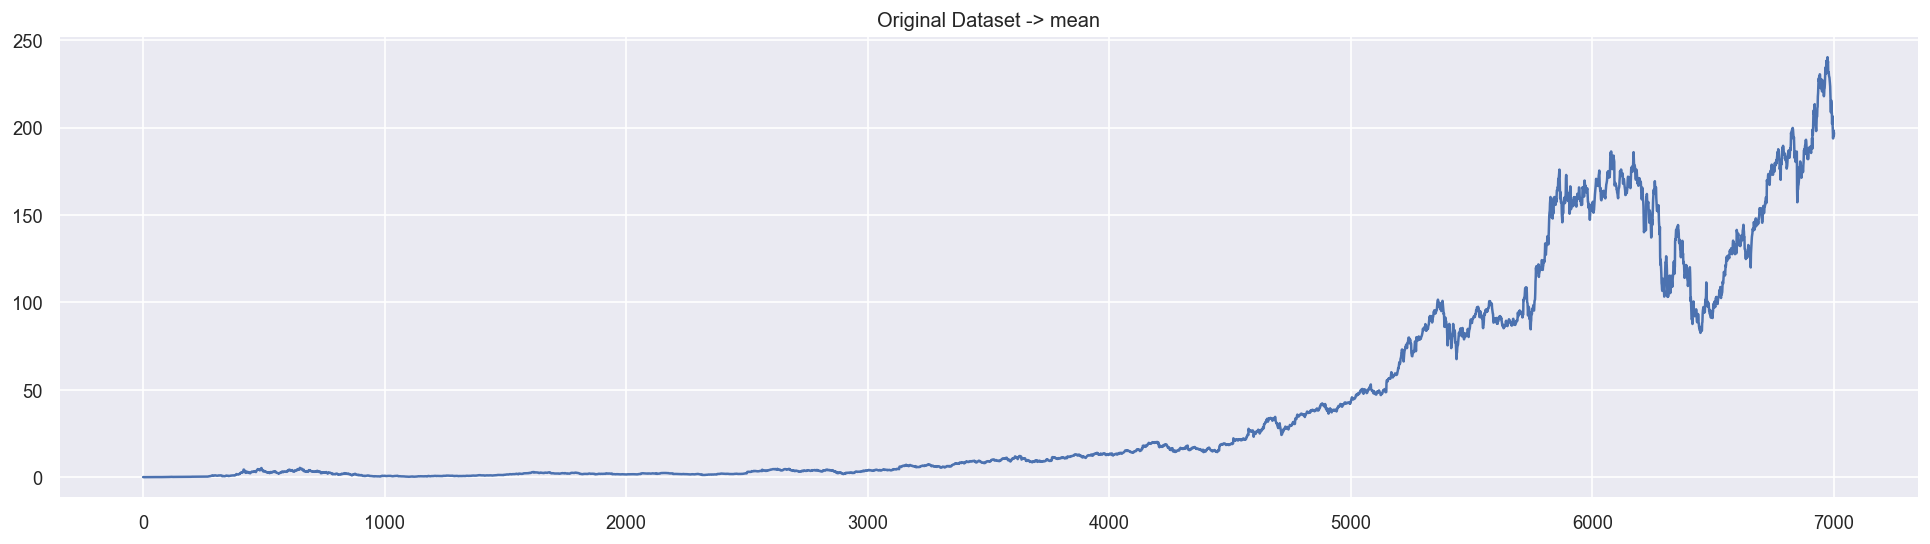

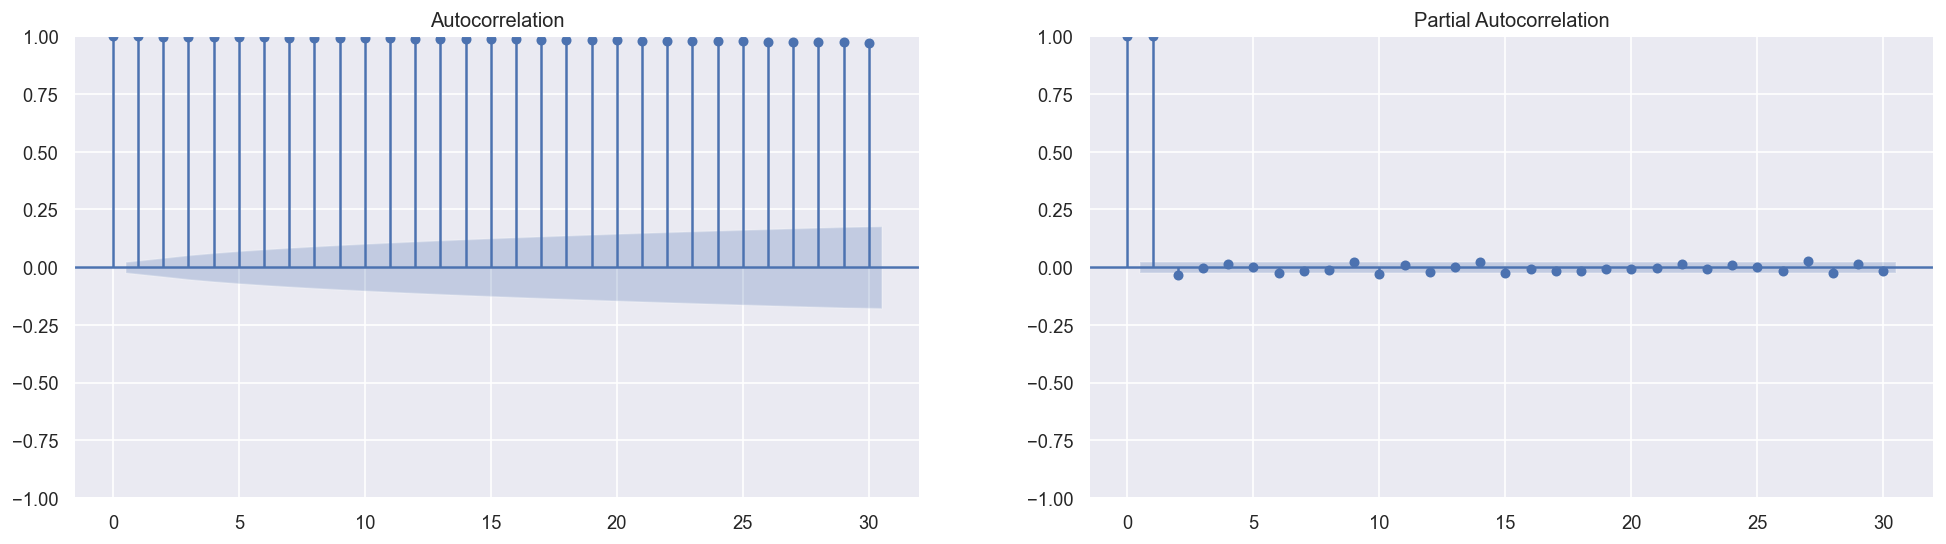

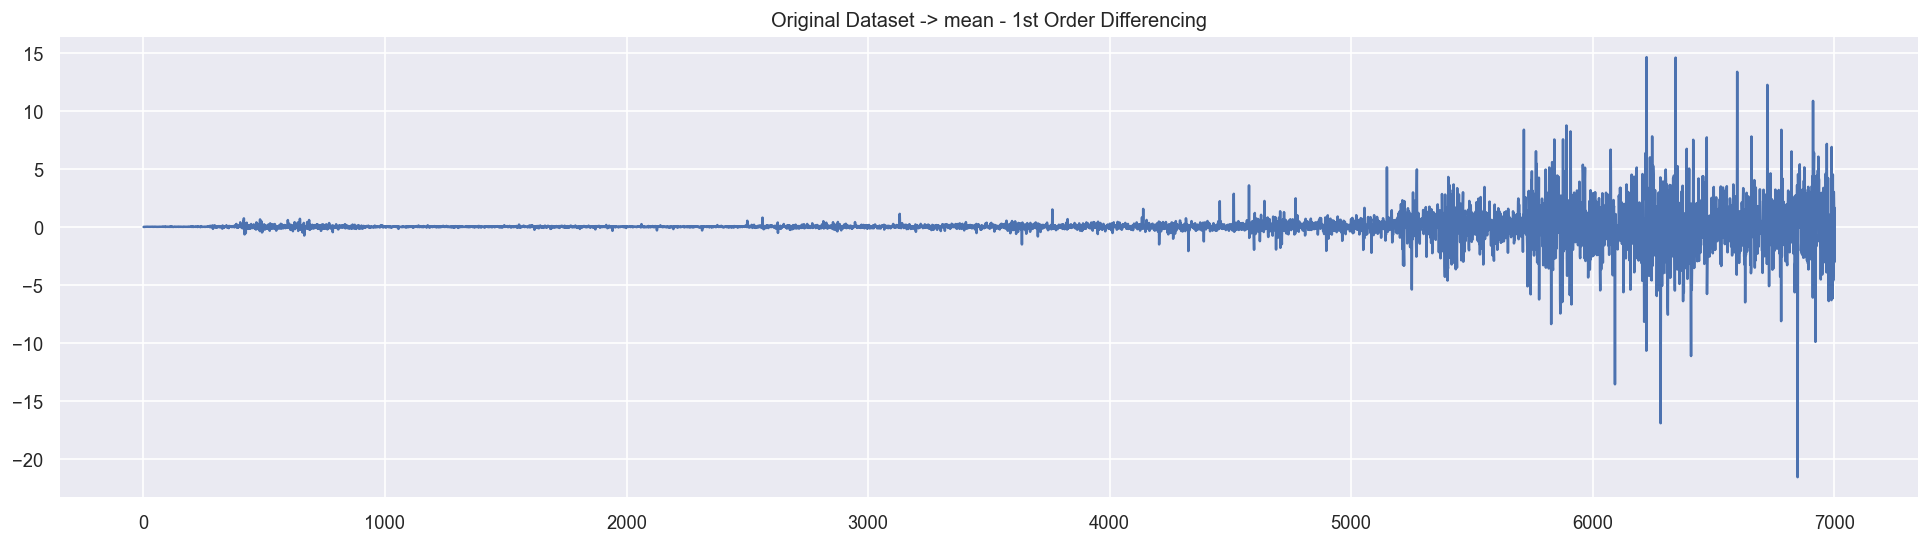

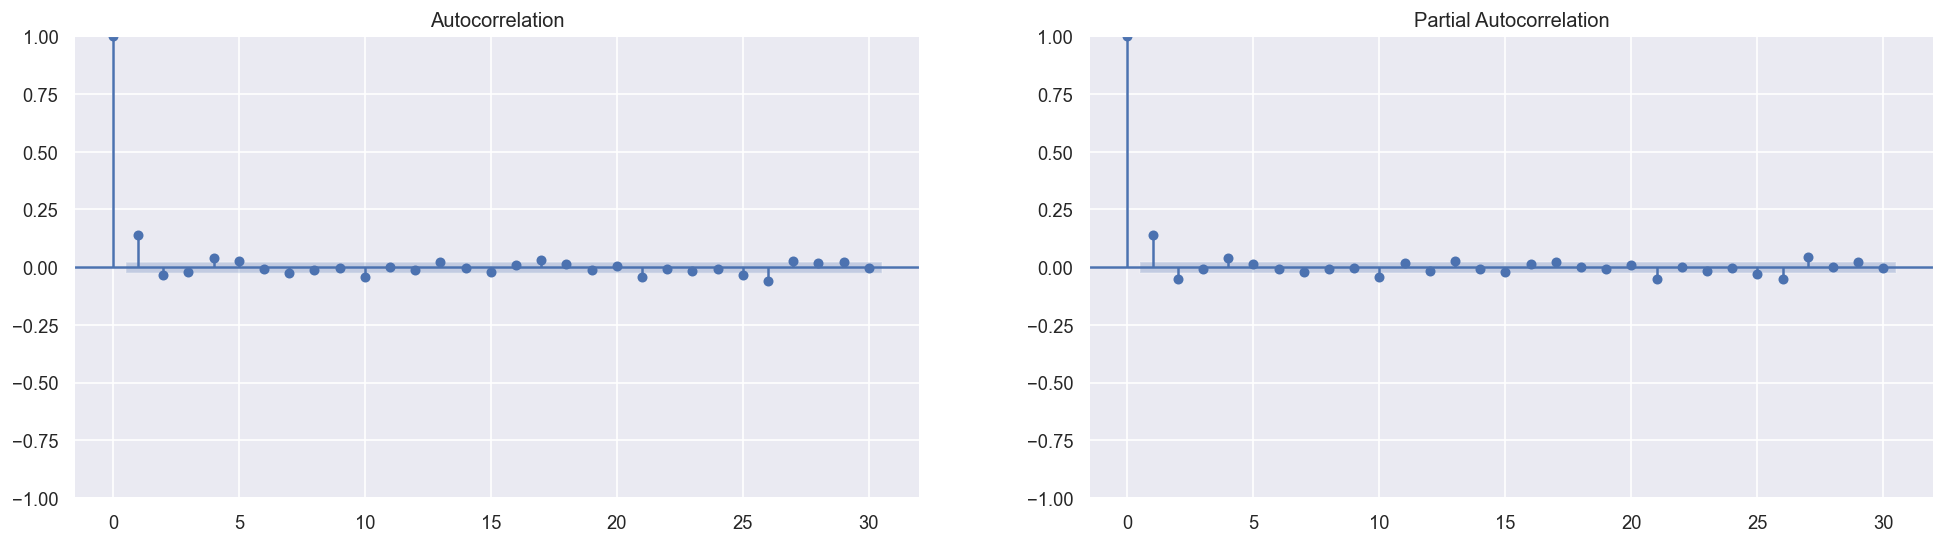

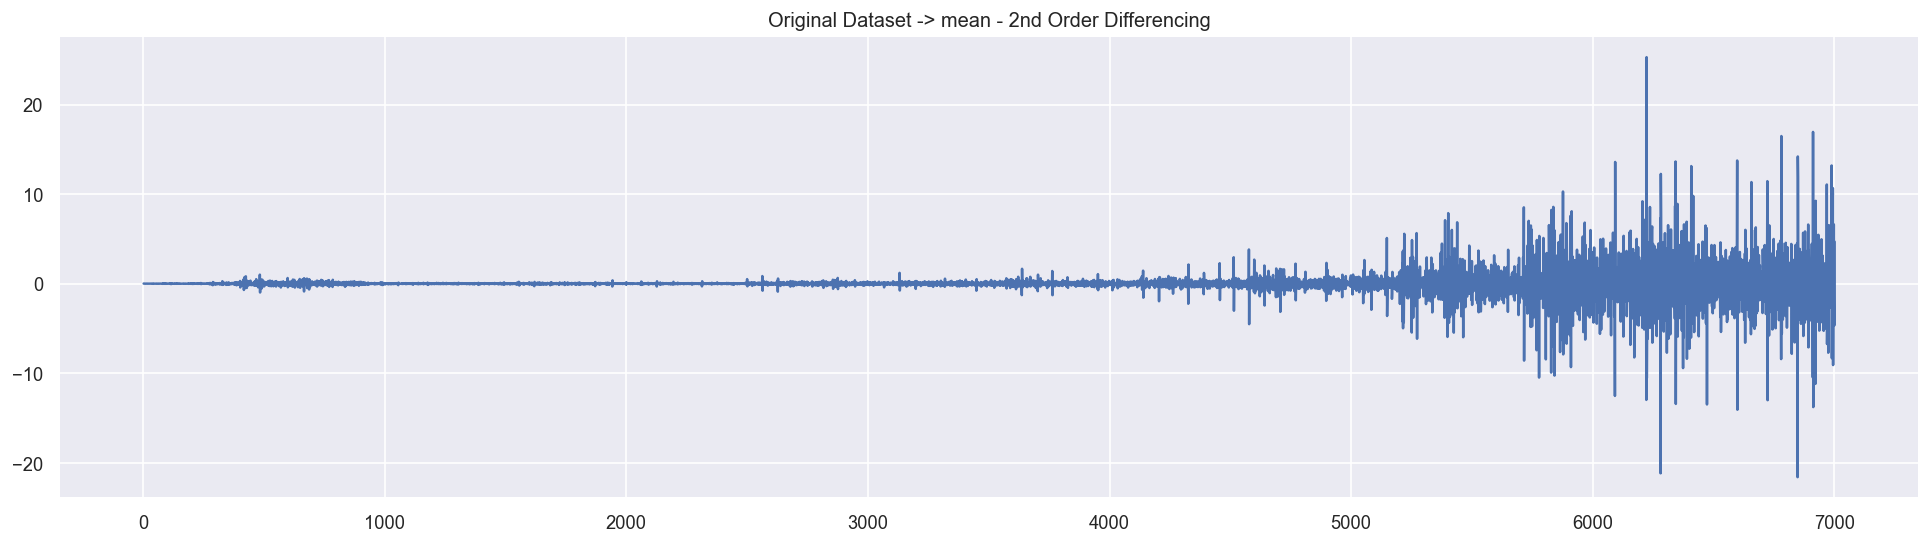

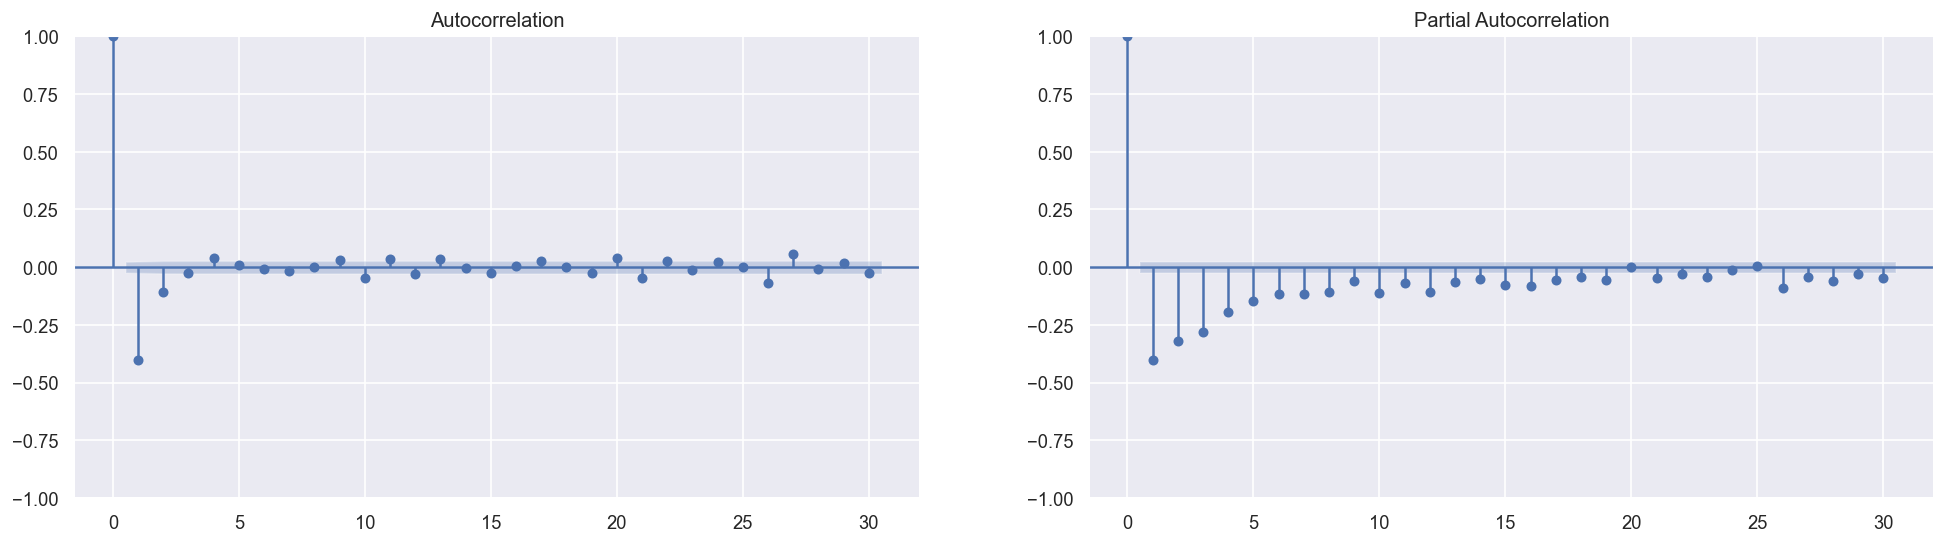

Train / Test based on:
order -> (1, 0, 1)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


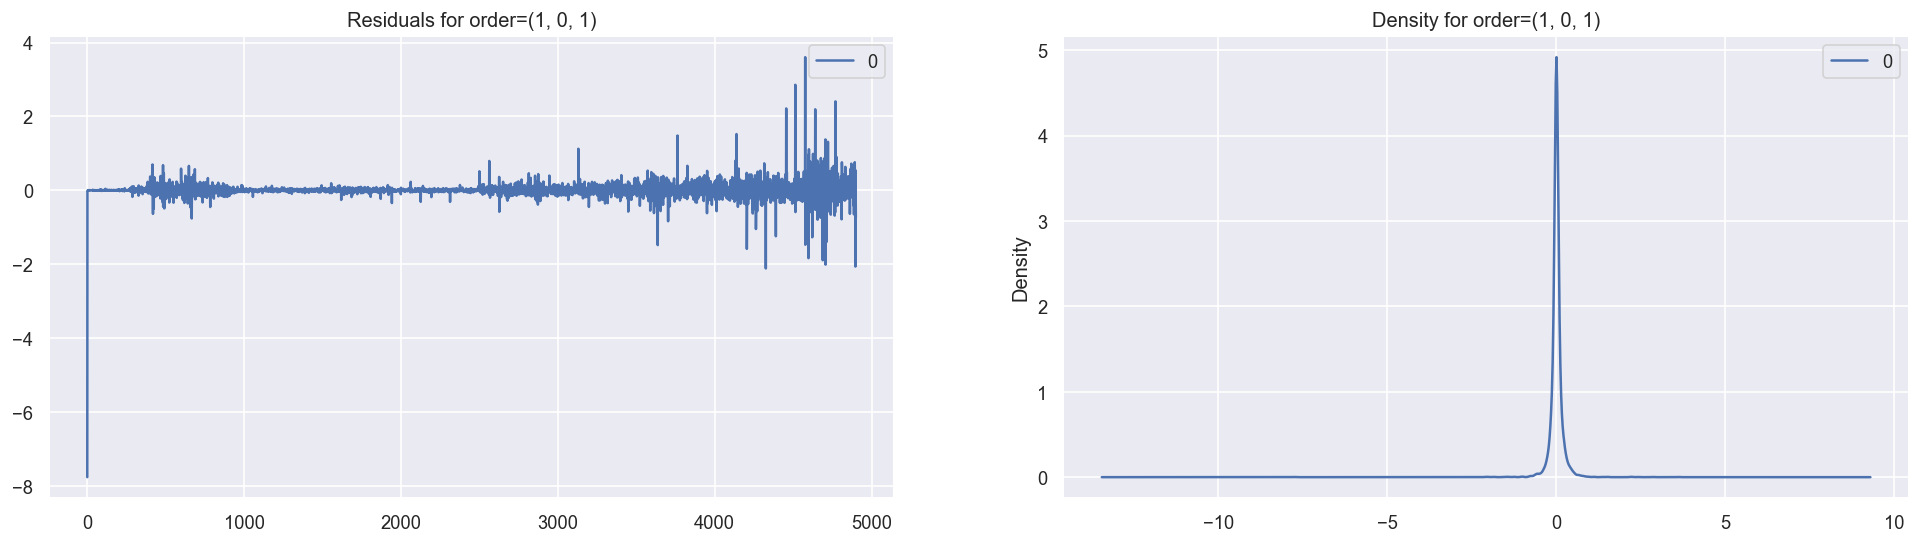

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


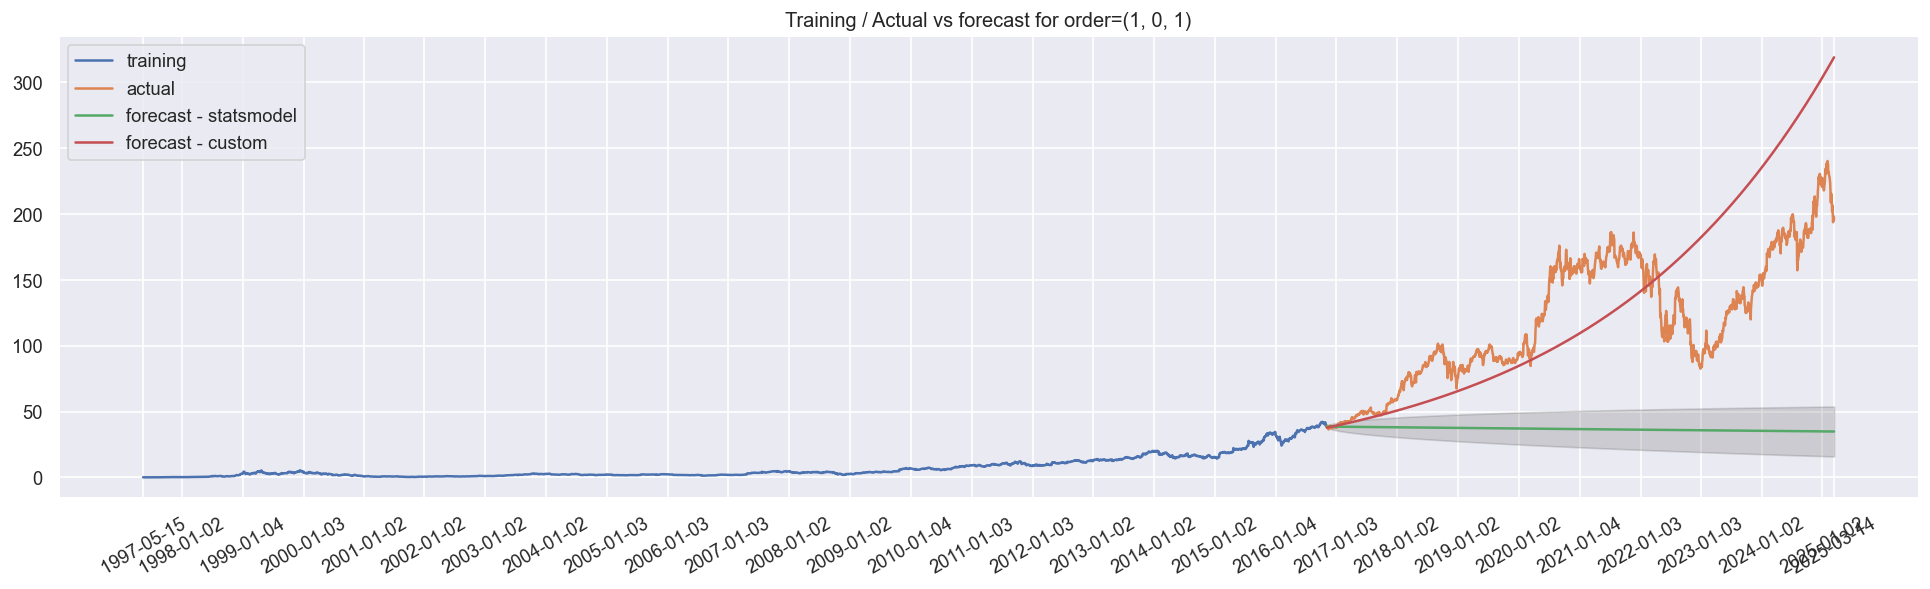

Train / Test based on:
order -> (1, 2, 1)
train_rate -> 0.7


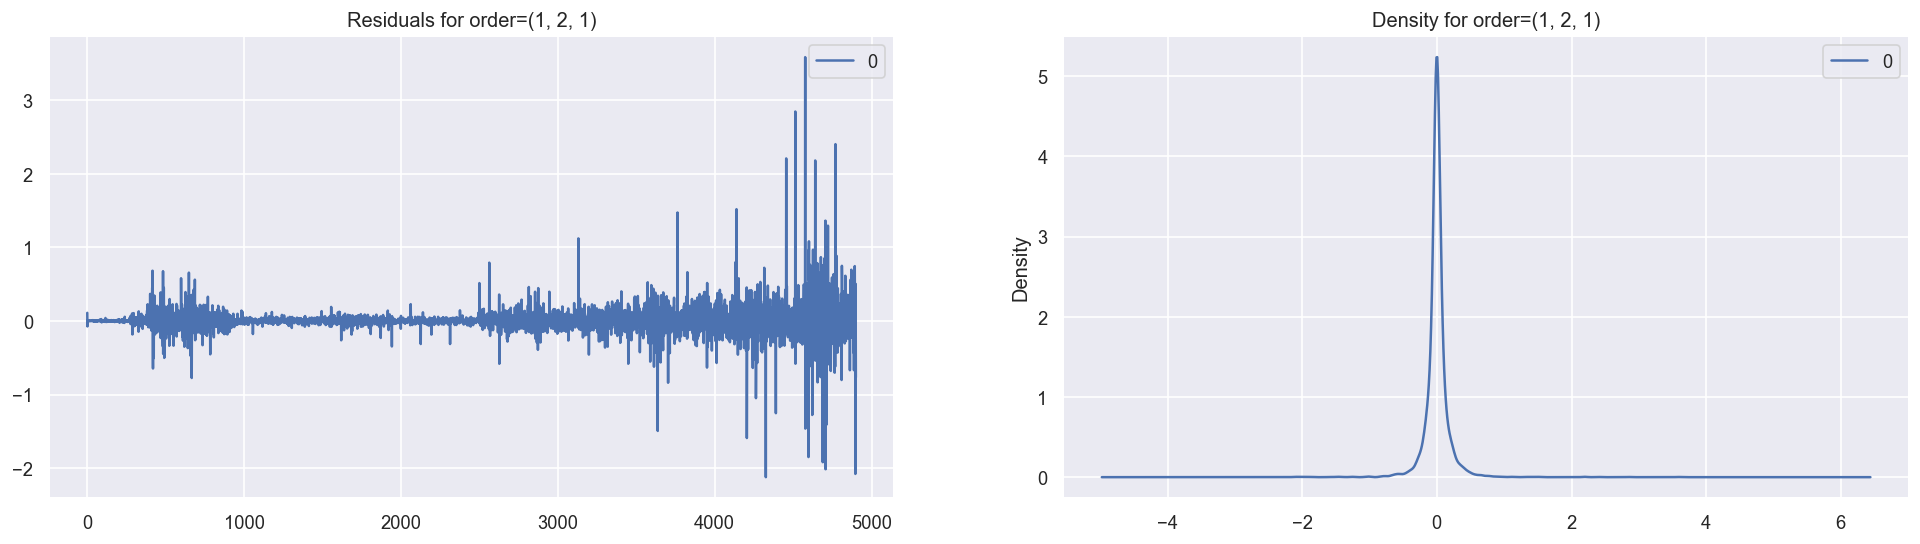

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


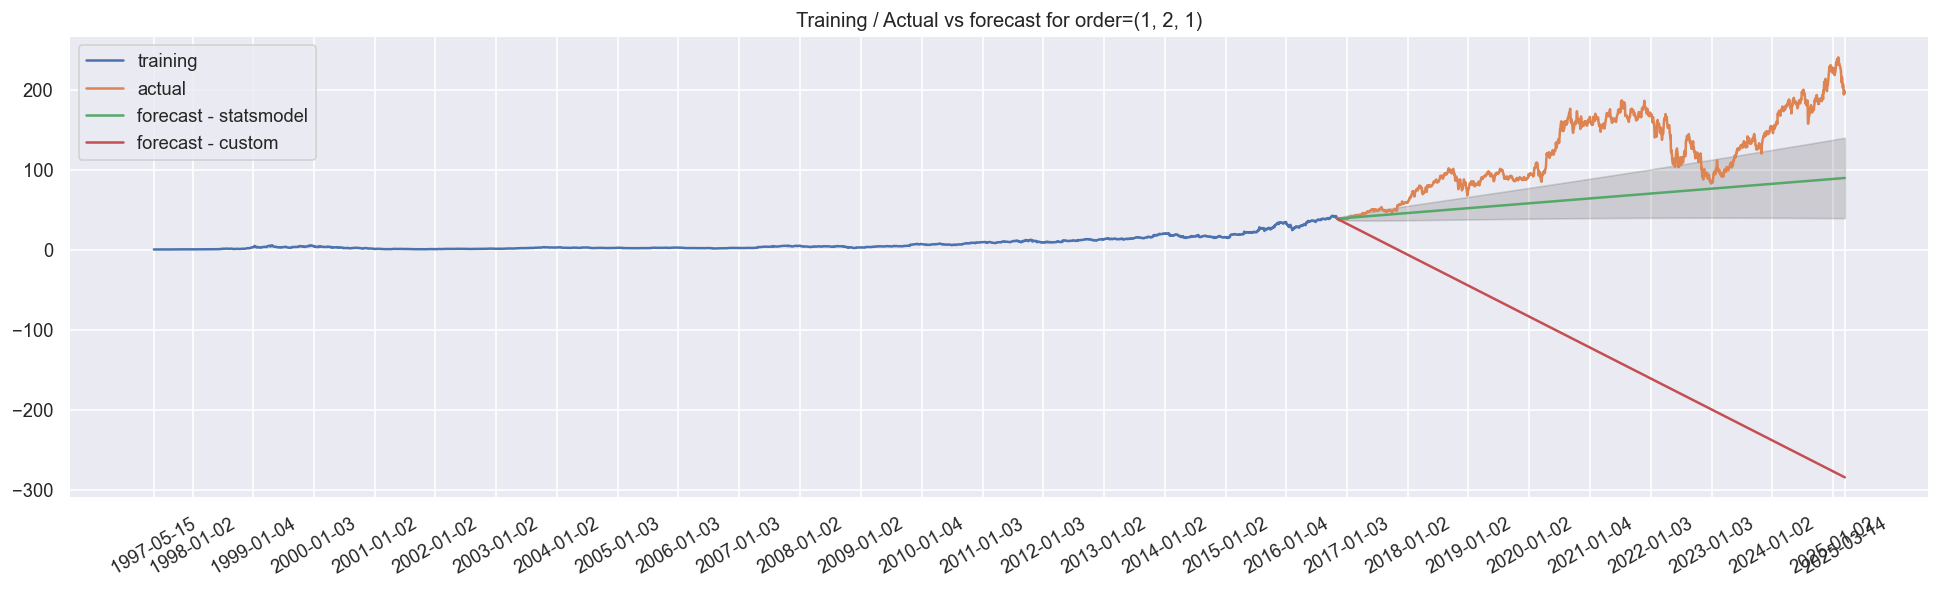

Train / Test based on:
order -> (3, 2, 3)
train_rate -> 0.7


c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


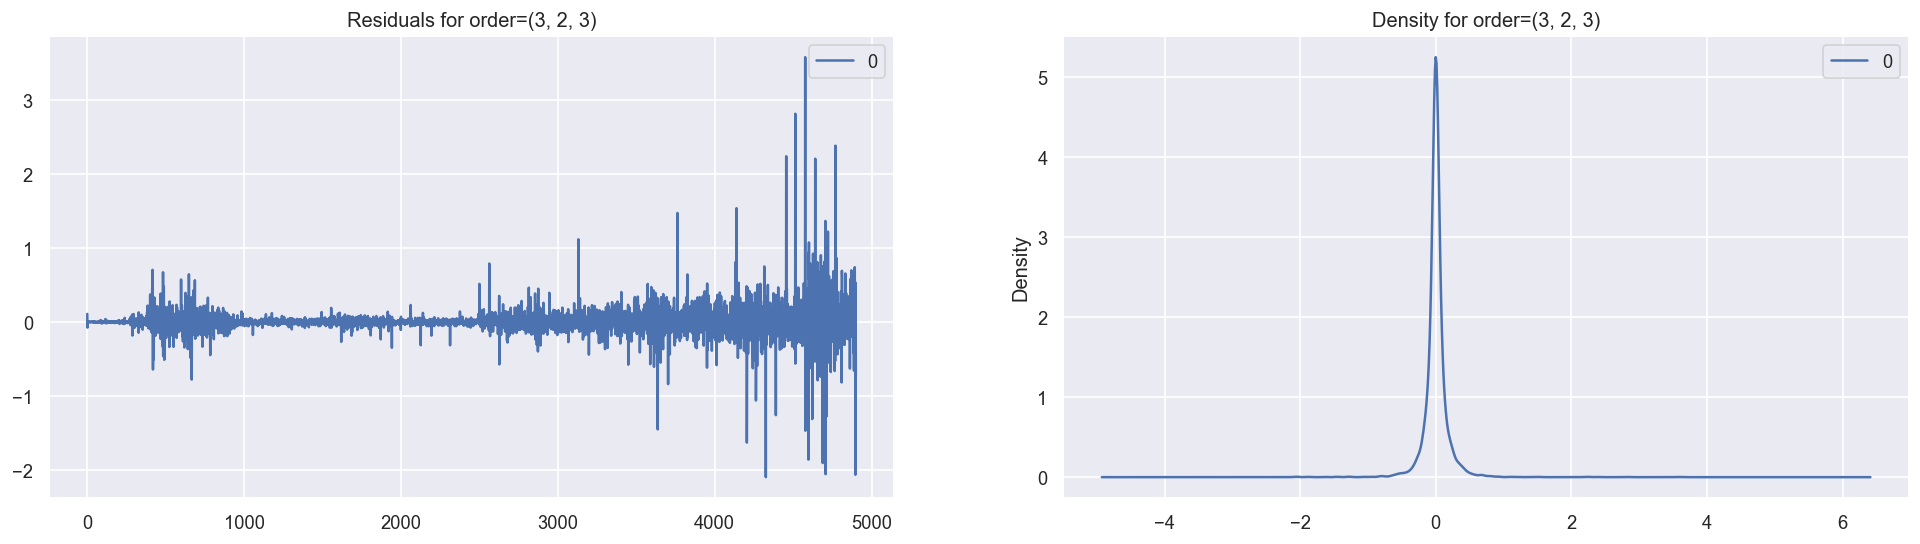

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


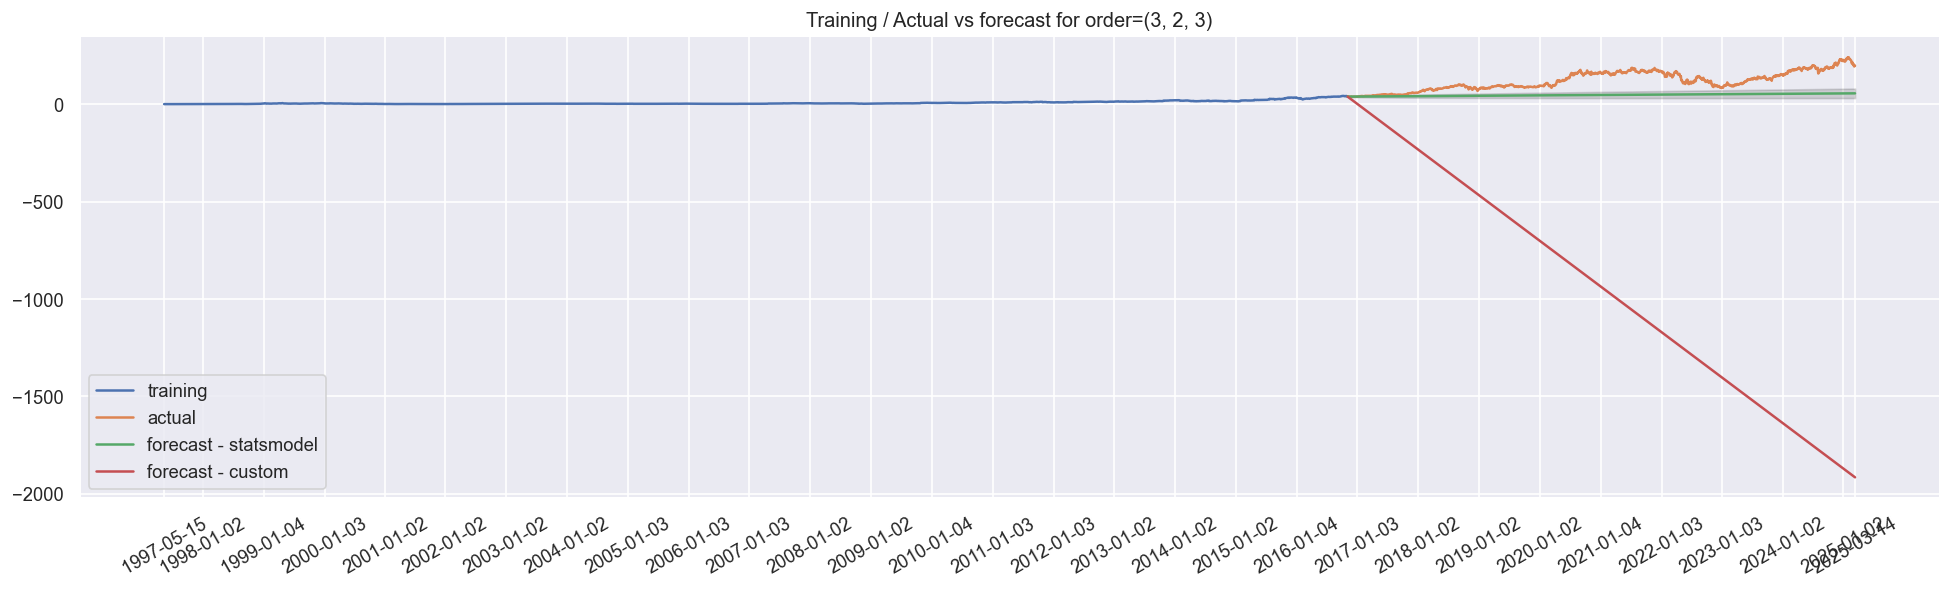

Train / Test based on:
order -> (5, 2, 2)
train_rate -> 0.7


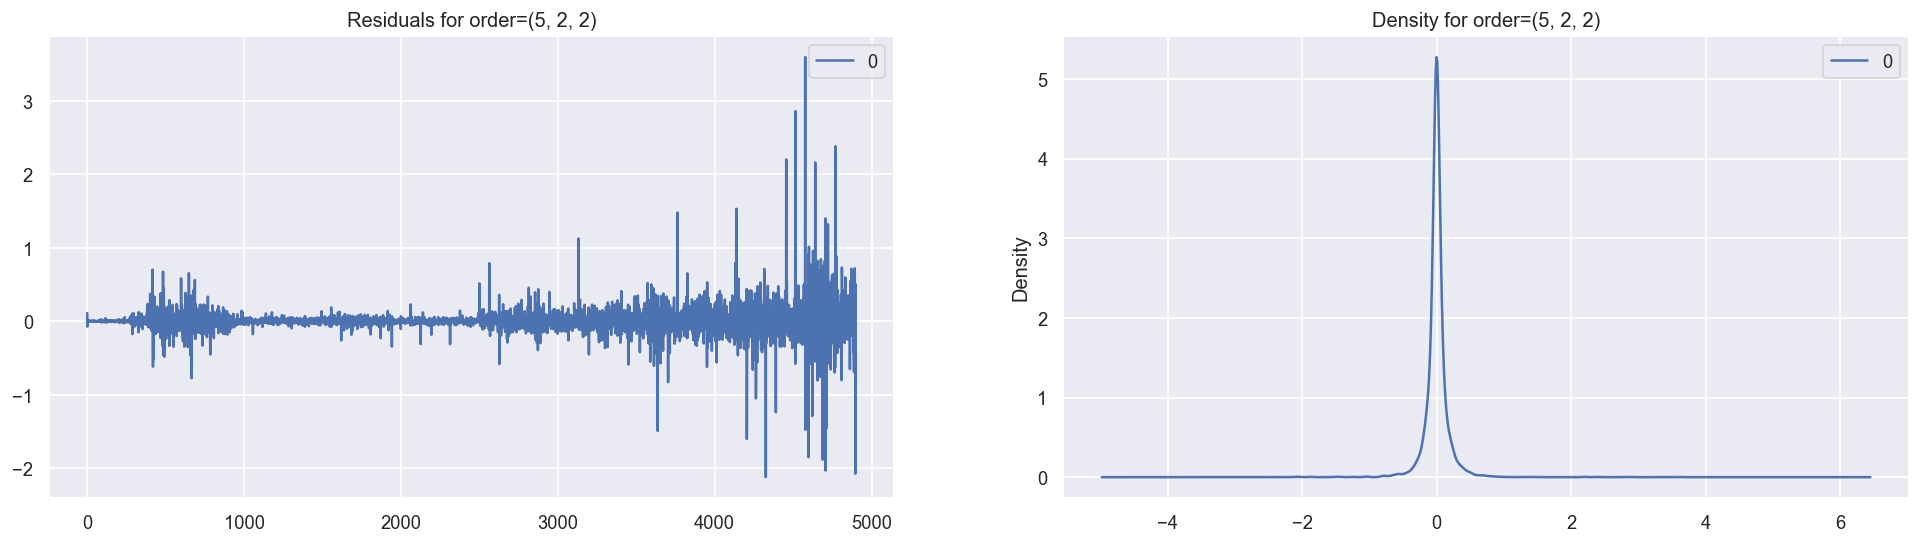

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


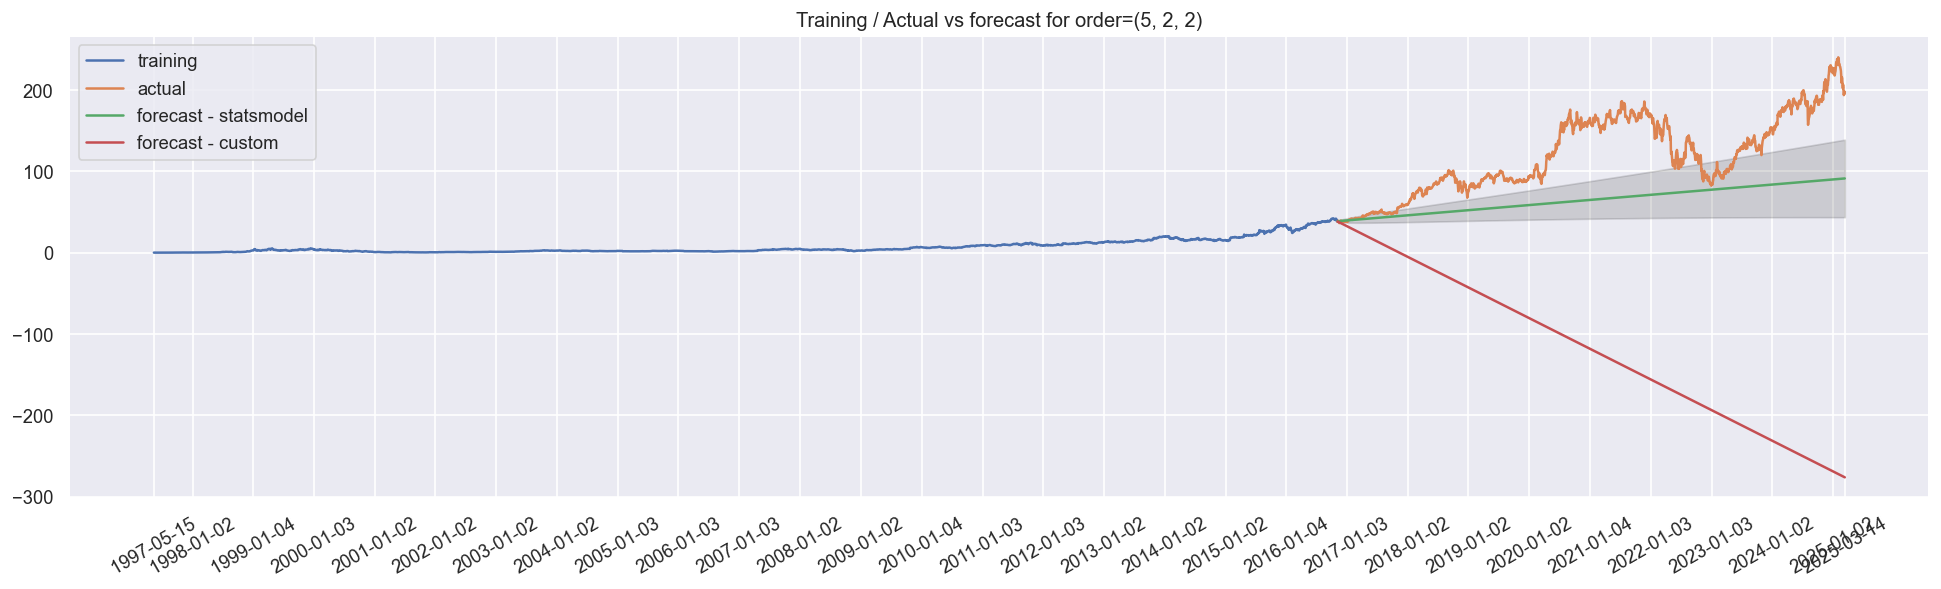

Train / Test based on:
order -> (None, None, None)
train_rate -> 0.8


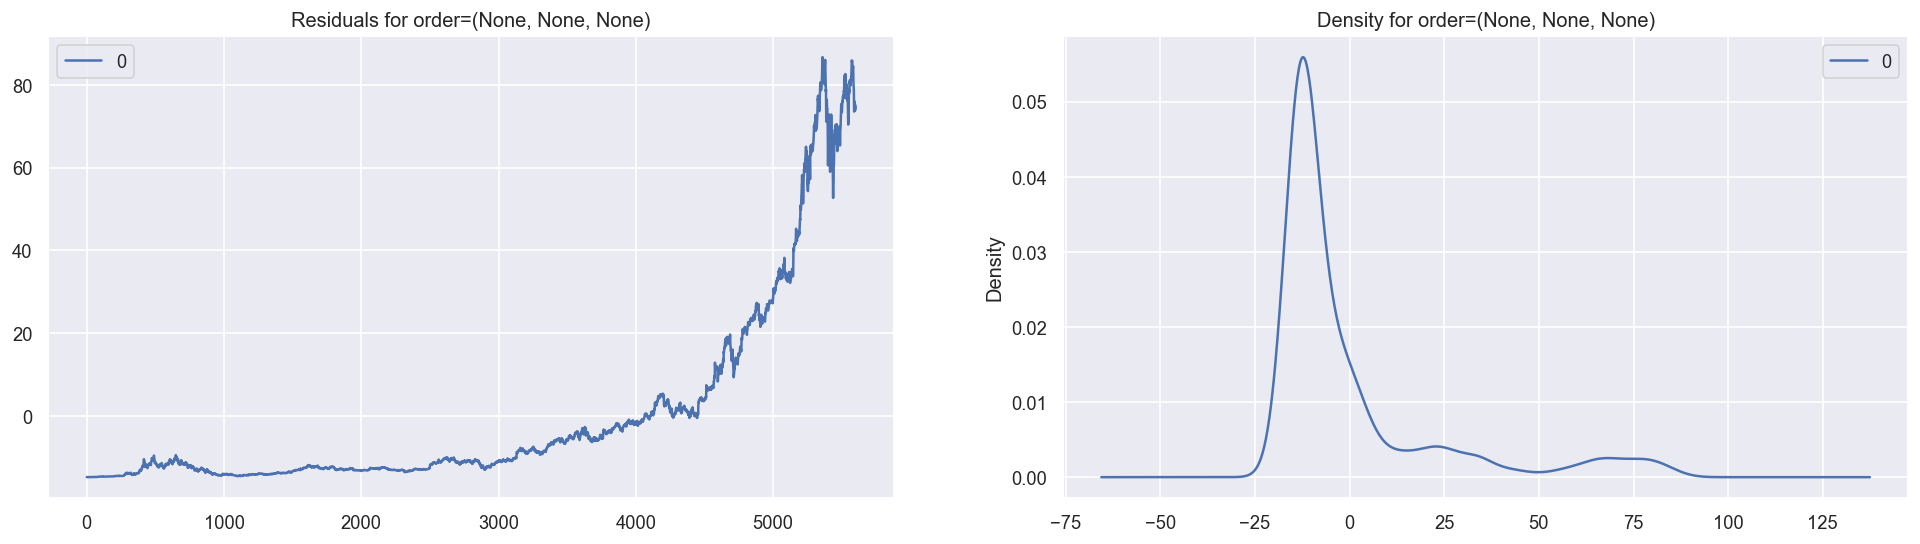

c:\Users\Roey\anaconda3\envs\advanced_ml\lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


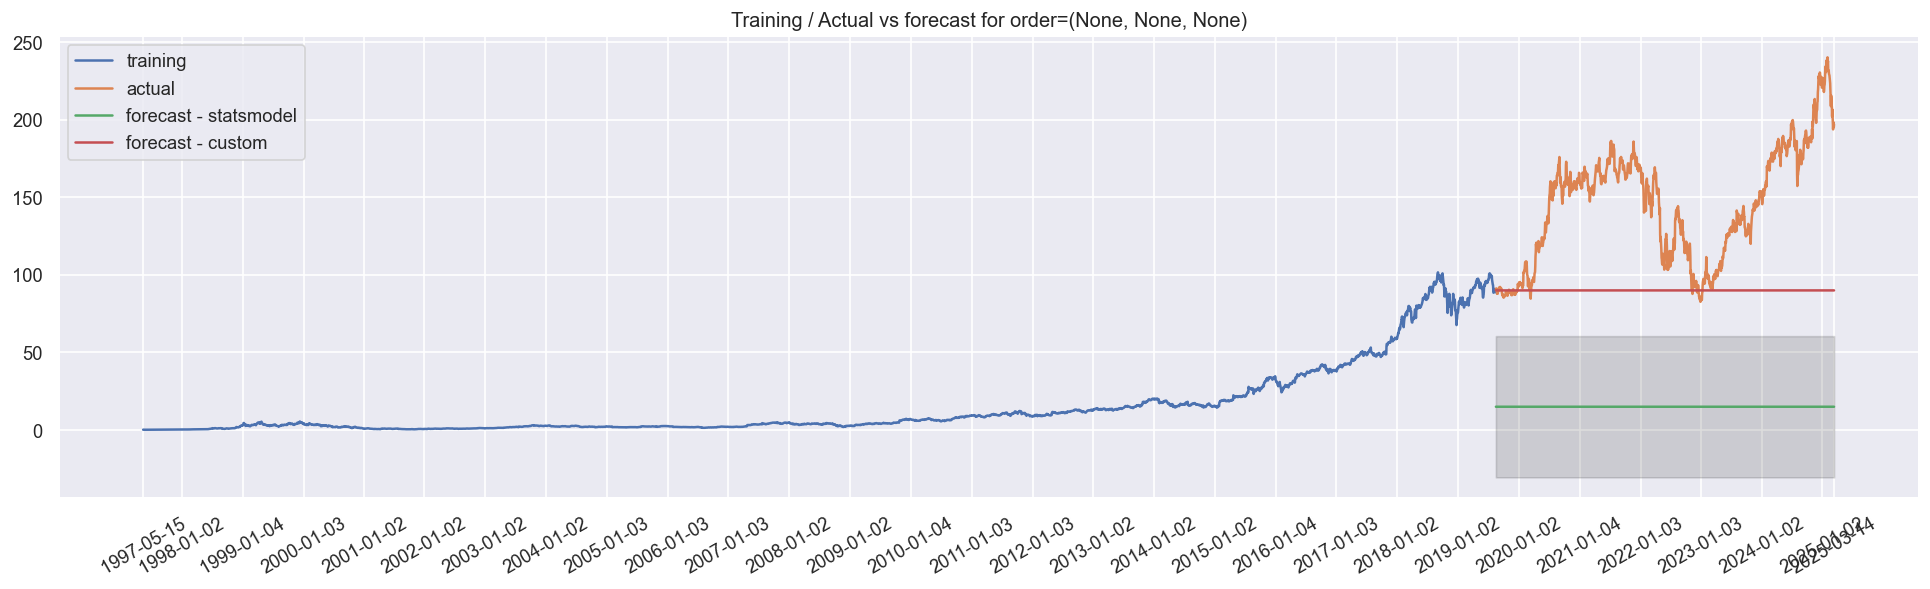

In [ ]:
hyperparams = [
    {"order": (1, 0, 1), "train_rate": 0.7},
    {
        #     "order": (1, 1, 1),
        #      "train_rate": 0.7
        # },{
        "order": (1, 2, 1),
        "train_rate": 0.7,
    },
    {
        #     "order": (3, 0, 3),
        #     "train_rate": 0.7
        # },{
        #     "order": (3, 1, 3),
        #      "train_rate": 0.7
        # },{
        "order": (3, 2, 3),
        "train_rate": 0.7,
    },
    {
        #     "order": (5, 0, 2),
        #     "train_rate": 0.7
        # },{
        #     "order": (5, 1, 2),
        #      "train_rate": 0.7
        # },{
        "order": (5, 2, 2),
        "train_rate": 0.7,
    },
    {"order": (None, None, None), "train_rate": 0.8},
]

# Monthly correlation
SAMPLES_PER_LAG = 30

for dataset_type, dataset in datasets.items():
    date_labels = get_date_labels_amzn(dataset)

    # print(date_labels)

    plot_acf(dataset.value, f"Original Dataset -> {dataset_type}", SAMPLES_PER_LAG)
    print(
        "=================================================================================================="
    )
    for idx, hyperparam in enumerate(hyperparams):
        predicted_dataset = run_arima_train_test(dataset, hyperparam, date_labels)
        print(
            "=================================================================================================="
        )

# Report

We've done a various of experiments and predictions using both the statsmodel Arima and the custom Arima
We found out the following measures:

1. We found out that train split of 0.8 gives the most realible forcast
2. Regarding the order values, we found out that _p_ and _q_ values of 1 don't give a great forecast, and the best is to use at least some days ago (we found 3 days as the most accurate) in order to get a correct forecast
3. Regarding the d value, we found out that 2nd order gives much more accurate results than the 1st order, because the stationarity is much stronger


# Use of generative AI

Please use the cell below to describe your use of generative AI in this assignment.


In this assignment we used ChatGPT in explenations and especially during the documentation part. We wanted to have an information about each term and what does it exactly means, so ChatGPT gave a great summary
